# Homework #4. Exploratory Data Analysis

In [ ]:
from datetime import datetime
print("EDA started:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

EDA started: 2025-11-11 17:26:46


EDA started: 2025-11-04 16:10:51

**Goal:** explore how discussion around *traditional wife*(tradwife) and related gender–role ideas evolved across Reddit communities during the last 5 years; examine whether this trend correlates with political changes in the USA.

Data: we collected posts from the following subreddits:

*   AskWomen
*   news
*   feminism
*   RedPillWomen
*   dating_advice
*   NoStupidQuestions
*   women

The dataset covers the period **from 2019.06 to 2024.08** every third month data is included.

We store submissions and posts in separate folders.

#0. Data sampling

As the period that was chosen for the analysis is quite large (5 years), it was crucial to optimize the process of data collection for efficient use of time and resourses. That is why we chose to implement two solutions:
1. Data smoothing. We sample one in three months each year: January, April, July, October.
2. We also add smaller samples in 2019 and 2024 years contaning only summer months to further analyze if there are any significant difference between the years.

However, it is important to consider possible seasonality in data, which is why in this section we explore if there is any seasonality regarding the topic of tradwives, using data on related terms on Google Trends.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

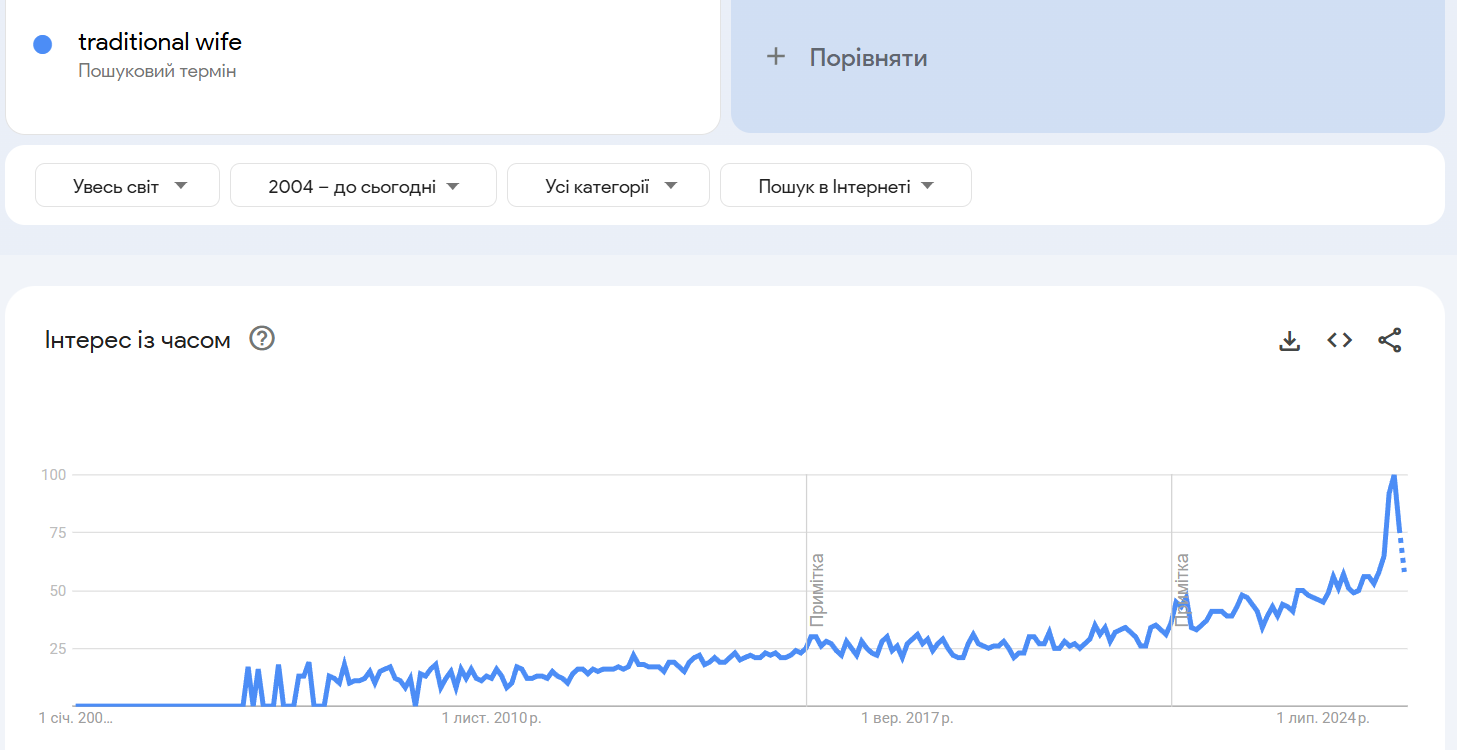

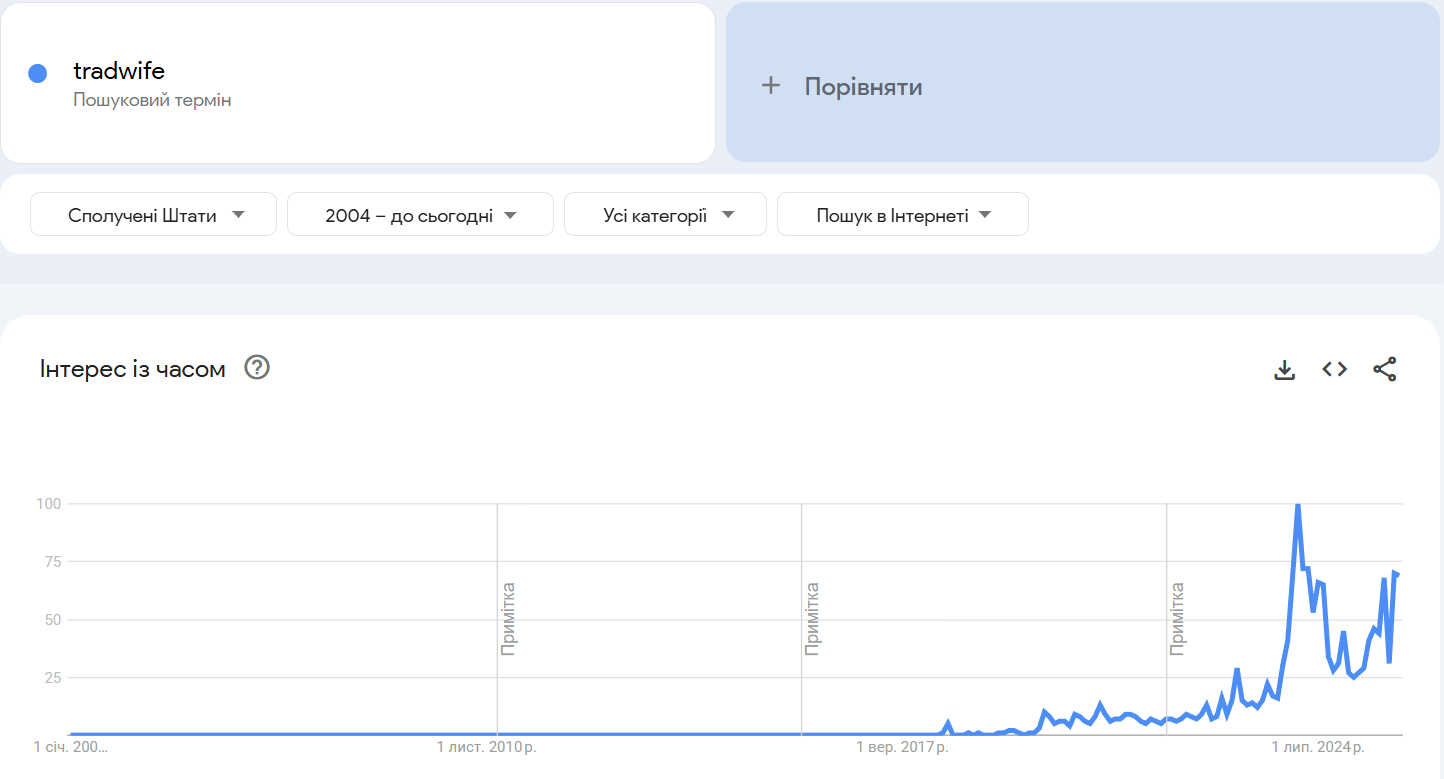

To analyze seasonality, we chose the term "traditional wife", since it simply has more records, and we chose the US region, since the reddit data will mostly cover it. Side note: by looking at these graphs we can already see the growing popularity of the topic.

In [ ]:
data = pd.read_csv('traditional_wife.csv')

data

,Місяць,traditional wife: (Сполучені Штати)
0,2004-01,0
1,2004-02,0
2,2004-03,0
3,2004-04,0
4,2004-05,0
...,...,...
258,2025-07,98
259,2025-08,77
260,2025-09,100
261,2025-10,80


In [ ]:
data = pd.read_csv('traditional_wife.csv')
data['Місяць'] = pd.to_datetime(data['Місяць'], format='%Y-%m')
# data = data[data['Місяць'] >= pd.to_datetime('2012-01')]
data.set_index('Місяць', inplace=True)
data["traditional wife: (Сполучені Штати)"] = (
    data["traditional wife: (Сполучені Штати)"]
    .replace(0, 0.1)
)

plt.figure(figsize=(12, 5))
plt.plot(data['traditional wife: (Сполучені Штати)'], label='Original Time Series', color='blue')
plt.suptitle('Original Time Series')
plt.legend()
plt.show()

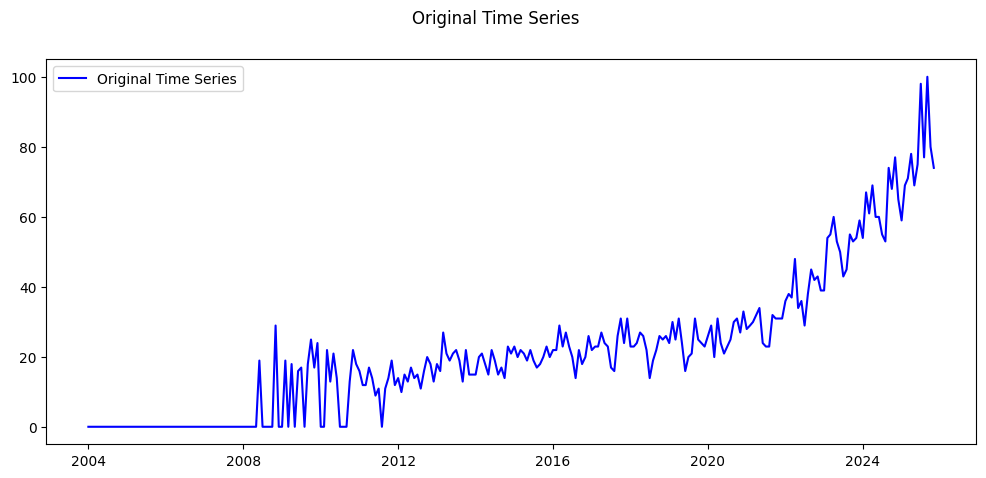

In [ ]:
data = pd.read_csv('traditional_wife.csv')
data['Місяць'] = pd.to_datetime(data['Місяць'], format='%Y-%m')
# data = data[data['Місяць'] >= pd.to_datetime('2012-01')]
data.set_index('Місяць', inplace=True)
data["traditional wife: (Сполучені Штати)"] = (
    data["traditional wife: (Сполучені Штати)"]
    .replace(0, 0.1)
)

plt.figure(figsize=(12, 5))
plt.plot(data['traditional wife: (Сполучені Штати)'], label='Original Time Series', color='blue')
plt.suptitle('Original Time Series')
plt.legend()
plt.show()

In [ ]:
# Decompose the time series into trend, seasonal and residual components
result = seasonal_decompose(
    data, model='multiplicative', extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

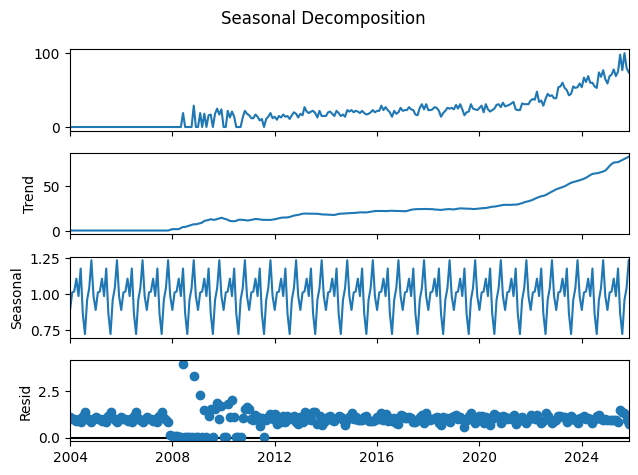

In [ ]:
# Decompose the time series into trend, seasonal and residual components
result = seasonal_decompose(
    data, model='multiplicative', extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

Let's try to remove the detected seasonality and see if the plot of the data changes much.

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(data, label='Original Time Series', color='blue')
data_without_seasonal = data['traditional wife: (Сполучені Штати)'] / result.seasonal

plt.plot(data_without_seasonal,
         label='Original Data without Seasonal Component', color='green')
plt.title('Time Series with and without Seasonal Component')
plt.xlabel('Year')
plt.ylabel('Popularity of the term')
plt.legend()
plt.show()

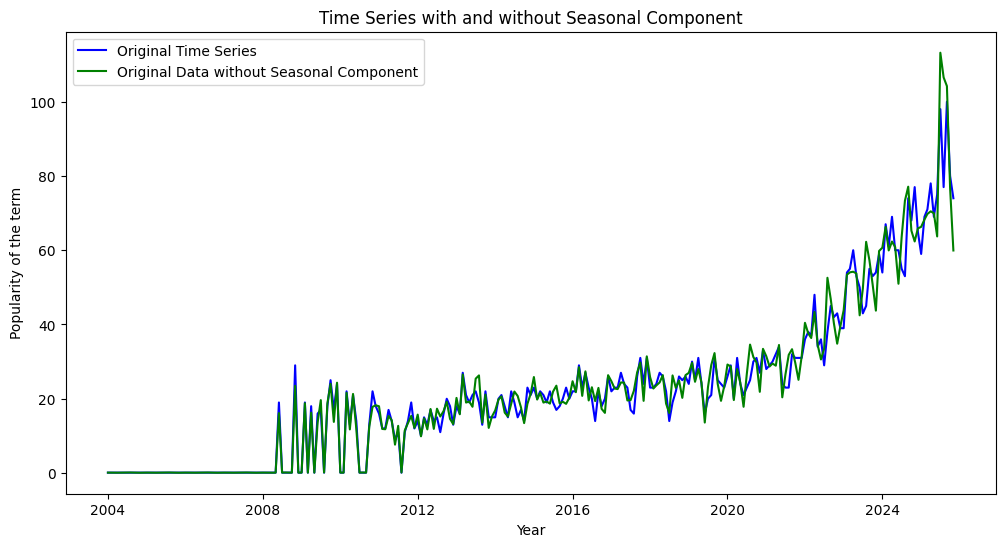

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(data, label='Original Time Series', color='blue')
data_without_seasonal = data['traditional wife: (Сполучені Штати)'] / result.seasonal

plt.plot(data_without_seasonal,
         label='Original Data without Seasonal Component', color='green')
plt.title('Time Series with and without Seasonal Component')
plt.xlabel('Year')
plt.ylabel('Popularity of the term')
plt.legend()
plt.show()

We'll also check if the seasonality over the year is present using some classical time series analysis tools: autocorrelation function and kruskal test.

In [ ]:
from scipy.stats import kruskal

groups = [group["traditional wife: (Сполучені Штати)"].values for name, group in data.groupby("Місяць")]
stat, p = kruskal(*groups)
print(p)  # p > 0.05 → no significant seasonal differences

0.48838093271664335


Conclusions: p-value obtained with Kruskal test is > 0.05, so there is no significant seasonality in the popularity in related topics. The autocorrelation function also shows no significant connnection between months separated in one year time.

Using these results, we justify the usage of strategies listed above.

#1. Overview

In [ ]:
#data is exported from Google Disk
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install vaderSentiment

In [ ]:
import pandas as pd
import re
import os
import glob
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import statsmodels.api as sm
from scipy.stats import spearmanr

In [ ]:
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="This pattern is interpreted as a regular expression, and has match groups."
)
warnings.simplefilter("ignore", SettingWithCopyWarning)

There are separate *submissions* and *comments* files, so at first we load them into two dataframes and then merge:

In [ ]:
df_sub = pd.read_csv("/content/drive/MyDrive/reddit datasets team 7 my disk/reddit datasets team 7/merged_submissions.csv")
df_com = pd.read_csv("/content/drive/MyDrive/reddit datasets team 7 my disk/reddit datasets team 7/merged_dataset.csv")

In [ ]:
df_sub.head()

,author,title,score,created,link,text,subreddit
0,[deleted],how do i overcome feeling sexually uncomfortab...,1,2020-07-01 03:00,https://www.reddit.com/r/AskWomen/comments/hiz...,removed,AskWomen
1,[deleted],when the ghoster comes back,5,2020-07-01 03:01,https://www.reddit.com/r/dating_advice/comment...,deleted,dating_advice
2,Bokb3o,what are liver spots?,2,2020-07-01 03:01,https://www.reddit.com/r/NoStupidQuestions/com...,older people start developing freckle-like spl...,NoStupidQuestions
3,[deleted],"republicans, but not the us president, now pus...",1,2020-07-01 03:01,https://www.reddit.com/r/news/comments/hize1v/...,deleted,news
4,_That_One_Fellow_,how much access can the work place actually ha...,2,2020-07-01 03:02,https://www.reddit.com/r/NoStupidQuestions/com...,my job site recently changed its wifi system t...,NoStupidQuestions


In [ ]:
df_com.head()

,author,score,created,link,body,title
0,Chief_B33f,4,2019-07-01 03:00:00,https://www.reddit.com/r/NoStupidQuestions/com...,we'd have ourselves a good ol fashioned war,NaN
1,iamusuallyright101,9,2019-07-01 03:00:00,https://www.reddit.com/r/news/comments/c7jkta/...,"okay sure, casino at fault... got it. but 3mil...",NaN
2,letsgetlostplz,1,2019-07-01 03:00:00,https://www.reddit.com/r/dating_advice/comment...,i am from canada! thank you i think he will ap...,NaN
3,thundersaurus_sex,-5,2019-07-01 03:00:00,https://www.reddit.com/r/news/comments/c7e4or/...,"except the proud boys are actual, literal nazi...",NaN
4,Hinter-Lander,1,2019-07-01 03:00:00,https://www.reddit.com/r/NoStupidQuestions/com...,dont get your hope's up that sounds like a pol...,NaN


The post and comment links are different, so we couldn't merge on them directly. At first we extracted the unique post_id(the common part of the URL) in both dataframes to create a new matching key. Then, grouped all comments by this new post_id and joined their text into one single string. Finally, merged this aggregated comments string back to the correct post using the post_id, giving one row per post.

In [ ]:
df_com_agg = df_com.dropna(subset=['body']).groupby('link')['body'].apply(
    lambda x: '; '.join(x.astype(str))
).reset_index().rename(columns={'body': 'all_comments'})


df_sub_prep = df_sub.rename(columns={'text': 'post_body'})

df_merged_posts = pd.merge(
    df_sub_prep,
    df_com_agg,
    on='link',
    how='left'
)

df_merged_posts['all_comments'] = df_merged_posts['all_comments'].fillna('')

In [ ]:
df_merged_posts.head()

,author,title,score,created,link,post_body,subreddit,post_id,all_comments
0,[deleted],how do i overcome feeling sexually uncomfortab...,1,2020-07-01 03:00,https://www.reddit.com/r/AskWomen/comments/hiz...,removed,AskWomen,hizdfr,hello nattbabee. thank you for participating i...
1,[deleted],when the ghoster comes back,5,2020-07-01 03:01,https://www.reddit.com/r/dating_advice/comment...,deleted,dating_advice,hizdjk,welcome to rdatingadvice! please keep the rule...
2,Bokb3o,what are liver spots?,2,2020-07-01 03:01,https://www.reddit.com/r/NoStupidQuestions/com...,older people start developing freckle-like spl...,NoStupidQuestions,hizdjp,older people start developing freckle-like spl...
3,[deleted],"republicans, but not the us president, now pus...",1,2020-07-01 03:01,https://www.reddit.com/r/news/comments/hize1v/...,deleted,news,hize1v,
4,_That_One_Fellow_,how much access can the work place actually ha...,2,2020-07-01 03:02,https://www.reddit.com/r/NoStupidQuestions/com...,my job site recently changed its wifi system t...,NoStupidQuestions,hizeg3,my job site recently changed its wifi system t...


Overall information about the submissions subfolder:

In [ ]:
df_merged_posts.shape

(2668413, 9)

In [ ]:
df_merged_posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2668413 entries, 0 to 2668412
Data columns (total 9 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   author        object
 1   title         object
 2   score         int64 
 3   created       object
 4   link          object
 5   post_body     object
 6   subreddit     object
 7   post_id       object
 8   all_comments  object
dtypes: int64(1), object(8)
memory usage: 183.2+ MB


Dataframe contains 2 668 413 records and 8 columns. 7 out of 8 columns' are of type *object*(probably strings) and one of them is of *int* type("score"). Memory usage is about 119 MB.  

*Describe* method applied to score column(the only numeric data):

In [ ]:
df_merged_posts[['score']].describe().T

,count,mean,std,min,25%,50%,75%,max
score,2668413.0,71.819047,1567.467521,0.0,1.0,1.0,1.0,247082.0


Mean post score is 72, but the standard deviation is extremely high(≈1557), which indicates large variability. A few posts receive very high scores while the majority gets minimal attention. At least 75% of posts have a score of 1, proving a highly skewed distribution.

*Describe* method might give us some insights about the rest of the data as well:

In [ ]:
df_merged_posts.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
author,2668413,792965,[deleted],598422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,2667256,2422504,deleted by user,44404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,2668413.0,NaN,NaN,NaN,71.819047,0.0,1.0,1.0,1.0,247082.0,1567.467521
created,2668413,NaN,NaN,NaN,2021-11-20 16:13:59.950668288,2019-06-01 03:00:00,2020-07-07 22:49:00,2021-10-05 19:04:00,2023-04-30 03:58:00,2024-09-01 02:57:00,NaN
link,2668413,2668413,https://www.reddit.com/r/NoStupidQuestions/com...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_body,1611867,763953,removed,477716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subreddit,2668413,7,NoStupidQuestions,1183427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,2668413,2668413,ckgkqk,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
all_comments,2668413,1305090,,1068098,NaN,NaN,NaN,NaN,NaN,NaN,NaN


At the *top* column we have values such as `[deleted]`, *deleted by user*, and *removed* for the *author*, *title*, and *text* fields.
It should be noted that during preprocessing, posts where both the title and text were deleted have been removed. This way, we can guarantee that each post has at least some meaningful content for analysis.

Also, the subreddit **NoStupidQuestions** dominated the dataset (nearly 45% of all posts), but this will be fixed once we extract posts concerning our topic.


#2. Activity and distribution

At first we edit the column 'created' so that it is in DateTime format. Also we create series *month_count* to group posts by month.

In [ ]:
df_merged_posts['created'] = pd.to_datetime(df_merged_posts['created'])
monthly_counts = (
    df_merged_posts['created']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

month_counts.head(10)

,count
created,
2019-06,90037
2019-07,101661
2019-08,105548
2019-09,492
2019-10,99699
2019-11,237
2020-01,100293
2020-02,400
2020-04,131041


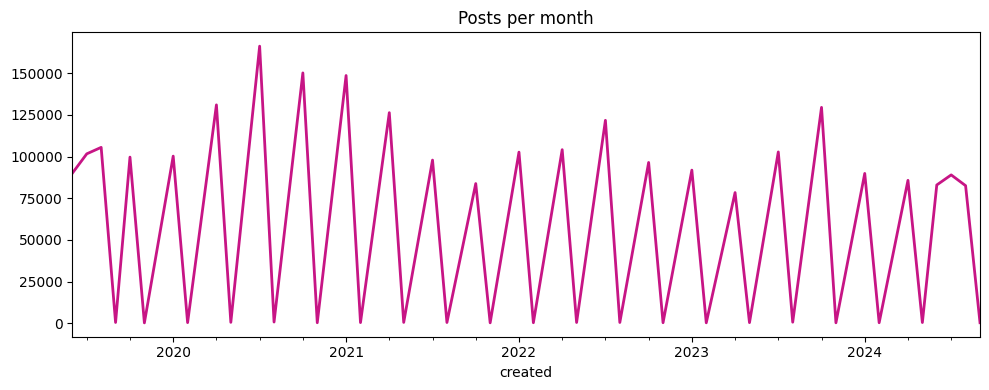

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
monthly_counts.plot(ax=ax, kind="line", color="mediumvioletred", title="Posts per month", linewidth=2)
plt.tight_layout()
plt.show()


There are 2 points to consider:

1. Data were extracted starting at 3 AM on the first day of each month and ending on the first day of the next one, which is why there is a small number of posts for every third month of the season (Feb, May, Aug, etc.). To simplify further analysis, we’ll delete those data; this won’t affect general trends.
2. There are months that will be used for particular hypothesis testing but don’t need to be in the overall analysis (2019-06, 2019-08, 2024-06, 2024-08); we’ll use a dataset without those as well.


In [ ]:
#keep only months with >= 1000 posts
per = df_merged_posts['created'].dt.to_period('M')
keep_months = per.value_counts()[lambda s: s >= 1000].index
df_big = df_merged_posts[per.isin(keep_months)].copy()

#from 2019-07 to 2024-07 only months Jan/Apr/Jul/Oct
start, end = pd.Timestamp('2019-07-01'), pd.Timestamp('2024-07-31 23:59:59')
df_q = df_big[
    df_big['created'].between(start, end)
    & df_big['created'].dt.month.isin([1, 4, 7, 10])
].copy()

Створено df_q з 2298468 рядками.
Розподіл за місяцями (мають бути 1, 4, 7, 10):
created
1     533444
4     525774
7     679458
10    559792
Name: count, dtype: int64


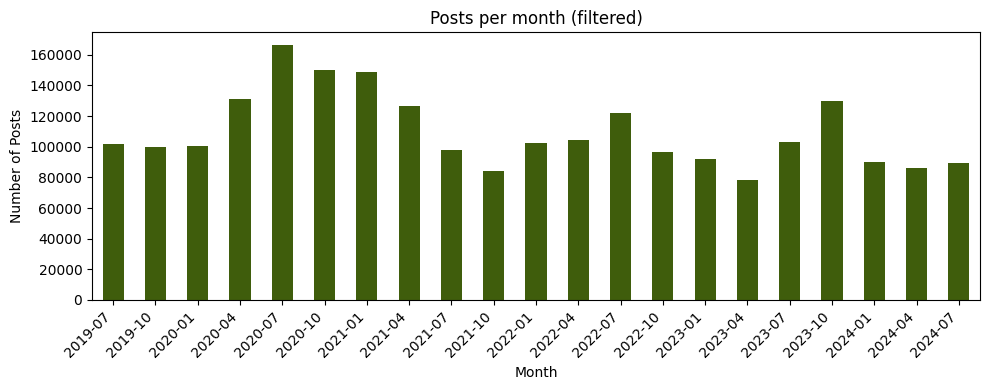

In [ ]:
month_counts = (
    df_q['created']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)
month_counts = month_counts.sort_index()

fig, ax = plt.subplots(figsize=(10,4))
month_counts.plot(kind='bar', color='#3f5d0c')
plt.title('Posts per month (filtered)')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The next chart shows the Gini coefficient of author concentration by subreddit:
values near **0** mean posts are evenly spread across authors, while values near **1** mean a few authors produce most posts.


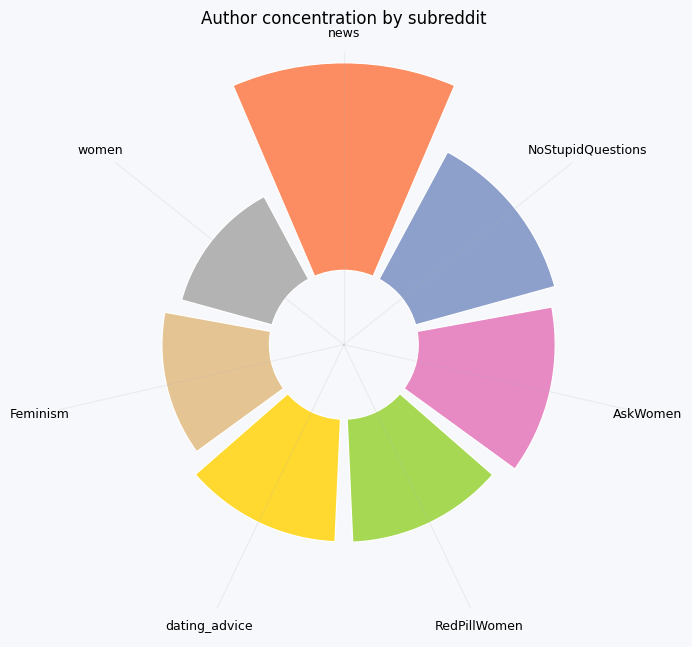

In [ ]:
def gini(x):
    x=np.sort(x.astype(float)); n=len(x)
    if n==0 or x.sum()==0: return np.nan
    c=np.cumsum(x); return (n+1-2*(c.sum()/c[-1]))/n

#convert data into gini per subreddit, top N for readability
g = (df_merged_posts
     .groupby(['subreddit','author']).size()
     .groupby('subreddit').apply(lambda s: gini(s.values))
     .dropna()
     .sort_values(ascending=False)
     .head(12))

#polar area
N=len(g); theta=np.linspace(0,2*np.pi,N,endpoint=False); width=2*np.pi/N
inner=0.22; radii=inner + 0.72*g.values
colors = plt.cm.Set2(np.linspace(0.15,0.95,N))

fig=plt.figure(figsize=(7,7), facecolor="#F6F8FB")
ax=fig.add_subplot(111, projection='polar'); ax.set_facecolor("#F6F8FB")
ax.set_theta_direction(-1); ax.set_theta_offset(np.pi/2)
ax.bar(theta, radii-inner, width=width*0.9, bottom=inner,
       color=colors, edgecolor="white", linewidth=0.9)

ax.set_xticks(theta); ax.set_xticklabels(g.index.tolist(), fontsize=9)
ax.set_yticks([]); ax.spines['polar'].set_visible(False); ax.grid(alpha=.18)
ax.set_title("Author сoncentration by subreddit", va='bottom', pad=18)
plt.tight_layout(); plt.show()


Next, we will explore how the above graphs change if we narrow data down to posts that fit our topic.

In [ ]:
keywords = [
    #traditional wife and related ideology
    "tradwife", "traditional wife", "traditional woman", "traditional women", "tradwives", "housewives", "trad wife",
    "housewife", "stay at home wife", "stay at home mom",
    #roles and ideology terms
    "femininity", "submission", "gender role", "family first", "from scratch cooking",
    "homemaker", "family values", "conservative woman", "tradlife",
    "anti-feminist", "homekeeper"
]

pattern = r"\b(" + "|".join(re.escape(word) for word in keywords) + r")\b"

df_filtered = df_merged_posts[
    df_merged_posts["post_body"].str.contains(pattern, case=False, na=False)
    | df_merged_posts["all_comments"].str.contains(pattern, case=False, na=False)
    | df_merged_posts["title"].str.contains(pattern, case=False, na=False)
    | df_merged_posts["link"].str.contains(pattern, case=False, na=False)
]

/tmp/ipython-input-2677688136.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_merged_posts["post_body"].str.contains(pattern, case=False, na=False)
/tmp/ipython-input-2677688136.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  | df_merged_posts["all_comments"].str.contains(pattern, case=False, na=False)  # <-- Додано
/tmp/ipython-input-2677688136.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  | df_merged_posts["title"].str.contains(pattern, case=False, na=False)
/tmp/ipython-input-2677688136.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  | df_merged_posts["link"].str.contains(pattern, case=False, na=False)


In [ ]:
df_filtered = df_filtered[
    df_filtered['created'].between('2019-07-01', '2024-07-31')
    & df_filtered['created'].dt.month.isin([1, 4, 7, 10])
].copy()

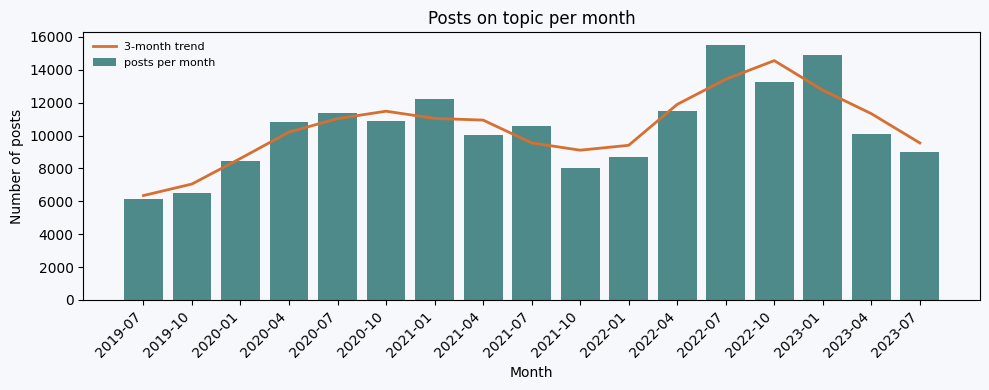

In [ ]:
month_counts_cleaned = month_counts[
    (month_counts >= 1000) &
    (month_counts.index >= pd.Period('2019-07', 'M')) &
    (month_counts.index <= pd.Period('2024-07', 'M')) &
    (month_counts.index.month.isin([1, 4, 7, 10]))
]

trend = month_counts_cleaned.rolling(3, center=True, min_periods=1).mean()

x_labels = month_counts_cleaned.index.astype(str)
x_positions = range(len(month_counts_cleaned))

fig, ax = plt.subplots(figsize=(10,4), facecolor="#F6F8FB")
ax.set_facecolor("#F6F8FB")

ax.bar(x_positions, month_counts_cleaned.values, color="#4F8A8B", label='posts per month')
ax.plot(x_positions, trend.values, color="#D76F30", linewidth=2, label='3-month trend')

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')

plt.title('Posts on topic per month')
plt.xlabel('Month')
plt.ylabel('Number of posts')
ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

Here we examine the distribution of posts across subreddits after filtering to the relevant data — both the absolute number of topic posts and their relative share of all posts.


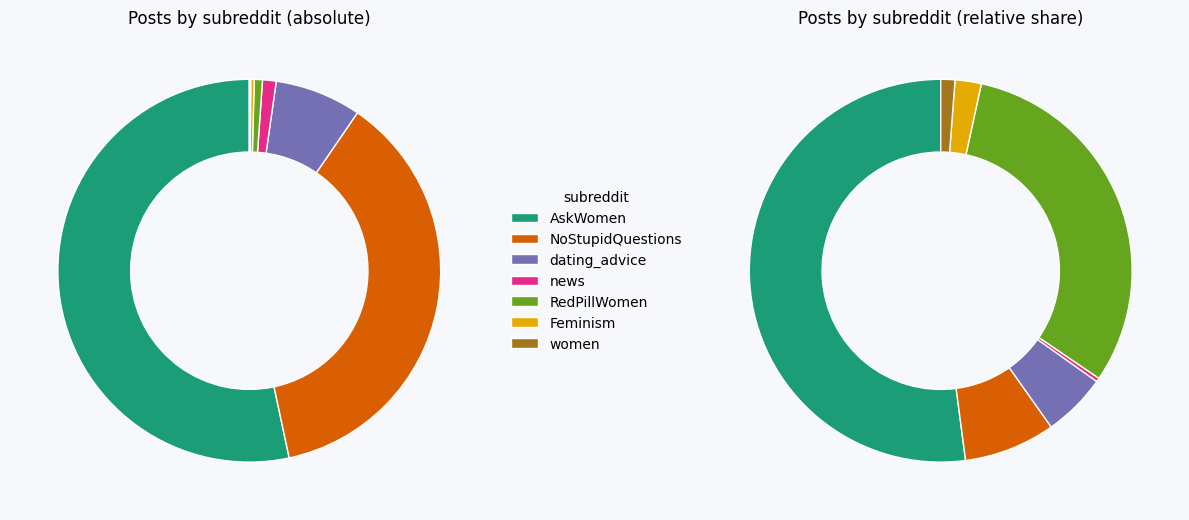

In [ ]:
#absolute and relative side-by-side donuts
subreddit_counts = df_filtered['subreddit'].value_counts()
subreddit_related = (
    df_filtered['subreddit'].value_counts()
    .div(df_q['subreddit'].value_counts(), fill_value=0)
).reindex(subreddit_counts.index).dropna()

import matplotlib.pyplot as plt, numpy as np
palette = list(plt.cm.Dark2.colors) + list(plt.cm.tab20.colors)
colors = (palette * ((len(subreddit_counts)//len(palette))+1))[:len(subreddit_counts)]

fig, axes = plt.subplots(1, 2, figsize=(12,6), facecolor="#F6F8FB")
for ax in axes: ax.set_facecolor("#F6F8FB")

axes[0].pie(subreddit_counts.values, startangle=90, colors=colors,
            wedgeprops=dict(width=0.38, edgecolor="white"))
axes[0].set_title("Posts by subreddit (absolute)")

axes[1].pie(subreddit_related.values, startangle=90, colors=colors[:len(subreddit_related)],
            wedgeprops=dict(width=0.38, edgecolor="white"))
axes[1].set_title("Posts by subreddit (relative share)")

axes[0].legend(subreddit_counts.index, title='subreddit',
               loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout(); plt.show()


Although most posts appear in NoStupidQuestions and AskWomen, the topic is proportionally common in RedPillWomen too.

#3. Content analysis

We are going to explore such hypotheses on our data:
1. Mentions of tradwife-related terms increase over time.
2. The sentiment in which the terms are used becomes more polarized.
3. Related posts attract more engagement (comments and upvotes).

**Hypothesis 1: Increasing trend in tradwife mentions**

H₀: No increasing trend (β ≤ 0)

H₁: Increasing trend (β > 0)

Method:
*   Poisson GLM with log offset for total posts → test β > 0
*   Spearman correlation
*   Visual trend plot


In [ ]:
# filter both dataframes up to 2023-07
df_filtered_cut = df_filtered[df_filtered['created'] <= '2023-07-31'].copy()
df_q_cut = df_q[df_q['created'] <= '2023-07-31'].copy()

# prep data
m = df_filtered_cut['created'].dt.to_period('M').value_counts().sort_index()
t = df_q_cut['created'].dt.to_period('M').value_counts().sort_index()

all_months = pd.period_range('2019-07', '2023-07', freq='M')
idx = all_months[all_months.month.isin([1, 4, 7, 10])]

m = m.reindex(idx, fill_value=0)
t = t.reindex(idx, fill_value=0)
rate = (m / t.replace(0, np.nan)) * 1000

print(f"Range: {idx[0]} to {idx[-1]} ({len(idx)} months)")
print(f"Mean rate: {rate.mean():.2f} per 1k posts\n")

Range: 2019-07 to 2023-07 (17 months)
Mean rate: 96.44 per 1k posts



In [ ]:
X = sm.add_constant(pd.DataFrame({'time': np.arange(len(idx))}))
fit = sm.GLM(m.values, X, family=sm.families.Poisson(),
             offset=np.log(t.values.clip(min=1))).fit()

beta = fit.params['time']
p_one = (fit.pvalues['time']/2) if beta > 0 else (1 - fit.pvalues['time']/2)

print(f"β = {beta:.6f} | p = {p_one:.4g}")
print(f"Monthly change: {np.expm1(beta):.2%}")
print(f"Result: {'REJECT H₀' if p_one < 0.05 else 'FAIL TO REJECT H₀'}\n")

β = 0.046685 | p = 0
Monthly change: 4.78%
Result: REJECT H₀



In [ ]:
mask = rate.notna()
rho, p_two = spearmanr(np.arange(mask.sum()), rate[mask].values)
p_one = (p_two/2) if rho > 0 else (1 - p_two/2)

print(f"ρ = {rho:.3f} | p = {p_one:.4g}")

ρ = 0.846 | p = 9.547e-06


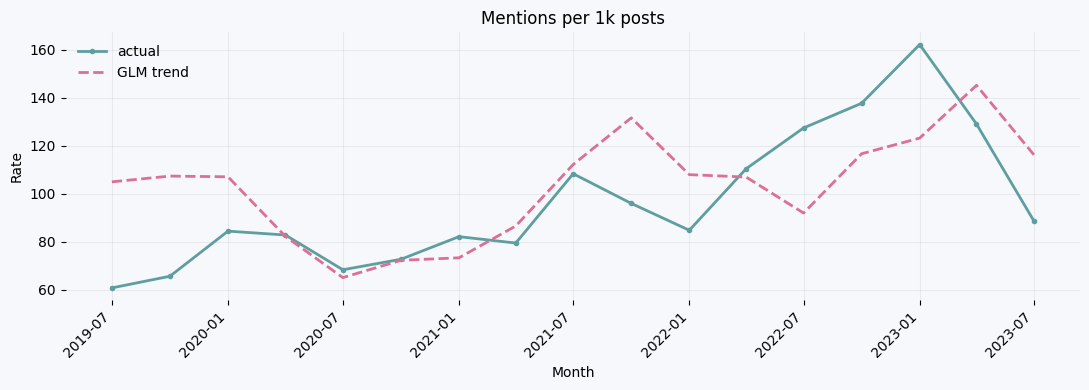


Pred rate range: 65.0 - 145.1
Actual rate range: 60.7 - 162.1


In [ ]:
pred_log_mentions = fit.predict(X)
pred_mentions = np.exp(pred_log_mentions)
pred_rate = (pred_mentions / t.values.clip(min=1)) * 10000000

fig, ax = plt.subplots(figsize=(11,4), facecolor="#F6F8FB")
ax.set_facecolor("#F6F8FB")
ax.plot(idx.to_timestamp(), rate.values, lw=2, color="cadetblue",
        marker='o', ms=3, label="actual")
ax.plot(idx.to_timestamp(), pred_rate, '--', lw=2, color="palevioletred",
        label="GLM trend")
ax.set_title("Mentions per 1k posts")
ax.set_xlabel("Month"); ax.set_ylabel("Rate")
ax.legend(frameon=False); ax.grid(alpha=.2)
[s.set_visible(False) for s in ax.spines.values()]
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print(f"\nPred rate range: {pred_rate.min():.1f} - {pred_rate.max():.1f}")
print(f"Actual rate range: {rate.min():.1f} - {rate.max():.1f}")

**Interpretation:**

The analysis confirms an increasing trend in tradwife-related mentions between July 2019 and July 2023.

The Poisson GLM shows us that mentions grew by approximately 4.78% each month, and p-value confirms that the trend is highly statistically significant (p < 0.001). This conclusion is supported by a Spearman correlation (ρ = 0.846), which means a positive relationship between time and mention frequency.

The visualization shows that early periods (2019-2020) showed relatively stable activity, but mentions increased sharply from 2021, doubling from around 60 to over 160 mentions per 1000 posts.

Overall we reject the null hypothesis and conclude that discussion of tradwife topics became more relevant in these Reddit communities over the study period.

**Hypothesis 2: Increasing sentiment polarization**

H₀: No increasing polarization (no trend in extreme sentiment share)

H₁: Increasing polarization (extreme sentiments grow over time)

Method:


*   Calculate VADER sentiment scores for title + post body
*   Categorize as Positive (≥0.4), Negative (≤-0.4), or Neutral
*   Test if proportion of extreme sentiments (Positive + Negative) increases over time using logistic regression
*   Visual: stacked bar chart of sentiment distribution



In [ ]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_vader(text):
    if pd.isna(text) or text == '':
        return 0
    try:
        return analyzer.polarity_scores(str(text))['compound']
    except:
        return 0

df_filtered_cut['combined_text'] = (
    df_filtered_cut['title'].fillna('') + ' ' +
    df_filtered_cut['post_body'].fillna('')
)
df_filtered_cut['sentiment'] = df_filtered_cut['combined_text'].apply(get_sentiment_vader)

def categorize_sentiment(score):
    if score >= 0.4:
        return 'Positive'
    elif score <= -0.4:
        return 'Negative'
    else:
        return 'Neutral'

df_filtered_cut['sentiment_cat'] = df_filtered_cut['sentiment'].apply(categorize_sentiment)
df_filtered_cut['is_extreme'] = df_filtered_cut['sentiment_cat'].isin(['Positive', 'Negative']).astype(int)

print(f"Sentiment distribution:")
print(df_filtered_cut['sentiment_cat'].value_counts(normalize=True))

Sentiment distribution:
sentiment_cat
Neutral     0.610825
Positive    0.223568
Negative    0.165607
Name: proportion, dtype: float64


In [ ]:
# monthly sentiment counts
monthly_sent = (
    df_filtered_cut.groupby([df_filtered_cut['created'].dt.to_period('M'), 'sentiment_cat'])
    .size()
    .unstack(fill_value=0)
)
monthly_sent = monthly_sent.reindex(idx, fill_value=0)[['Negative', 'Neutral', 'Positive']]

monthly_sent['total'] = monthly_sent.sum(axis=1)
monthly_sent['extreme'] = monthly_sent['Negative'] + monthly_sent['Positive']
monthly_sent['extreme_pct'] = (monthly_sent['extreme'] / monthly_sent['total'] * 100).fillna(0)

print(f"\nExtreme sentiment share over time:")
print(f"Start: {monthly_sent['extreme_pct'].iloc[0]:.1f}%")
print(f"End: {monthly_sent['extreme_pct'].iloc[-1]:.1f}%")


Extreme sentiment share over time:
Start: 39.6%
End: 49.2%


In [ ]:
#logistic regression for polarization trend
df_monthly = df_filtered_cut.copy()
df_monthly['time'] = df_monthly['created'].dt.to_period('M').map({p: i for i, p in enumerate(idx)})
df_monthly = df_monthly[df_monthly['time'].notna()]

X_lr = sm.add_constant(df_monthly[['time']])
y_lr = df_monthly['is_extreme']

model_full = sm.Logit(y_lr, X_lr).fit(disp=0)
model_null = sm.Logit(y_lr, sm.add_constant(np.ones(len(y_lr)))).fit(disp=0)

from scipy.stats import chi2
lr_stat = 2 * (model_full.llf - model_null.llf)
p_val = chi2.sf(lr_stat, 1) / 2

beta_polar = model_full.params['time']
print(f"\nLogistic regression:")
print(f"β = {beta_polar:.6f} | p = {p_val:.4g}")
print(f"Result: {'REJECT H₀' if p_val < 0.05 else 'FAIL TO REJECT H₀'}")


Logistic regression:
β = 0.008202 | p = 1.683e-15
Result: REJECT H₀


In [ ]:
#spearman for extreme
rho_polar, p_two_polar = spearmanr(np.arange(len(idx)), monthly_sent['extreme_pct'].values)
p_one_polar = (p_two_polar/2) if rho_polar > 0 else (1 - p_two_polar/2)

print(f"\nSpearman (extreme %):")
print(f"ρ = {rho_polar:.3f} | p = {p_one_polar:.4g}")


Spearman (extreme %):
ρ = 0.363 | p = 0.07621


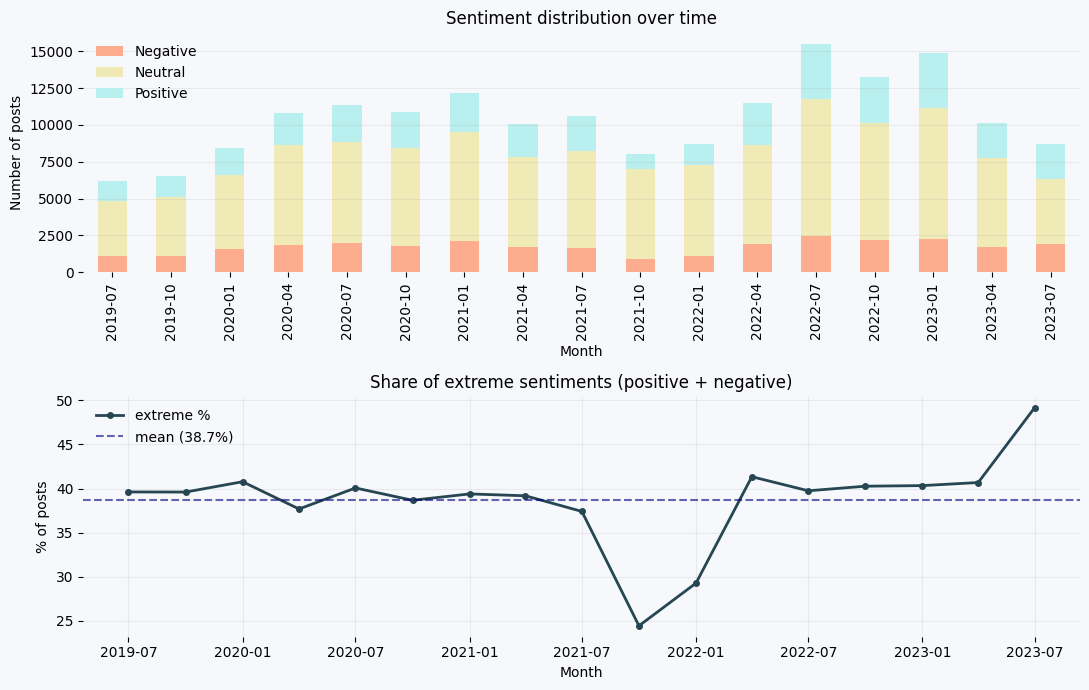

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), facecolor="#F6F8FB")

monthly_sent[['Negative', 'Neutral', 'Positive']].plot(
    kind='bar', stacked=True, ax=ax1,
    color=['lightsalmon', 'palegoldenrod', 'paleturquoise'], alpha=0.85
)
ax1.set_facecolor("#F6F8FB")
ax1.set_title("Sentiment distribution over time")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of posts")
ax1.legend(frameon=False, loc='upper left')
ax1.grid(alpha=.2, axis='y')
[s.set_visible(False) for s in ax1.spines.values()]

#extreme sentiment %
ax2.set_facecolor("#F6F8FB")
ax2.plot(idx.to_timestamp(), monthly_sent['extreme_pct'].values,
         lw=2, color="#264653", marker='o', ms=4, label="extreme %")
ax2.axhline(monthly_sent['extreme_pct'].mean(), ls='--', color='navy',
            alpha=0.6, label=f"mean ({monthly_sent['extreme_pct'].mean():.1f}%)")
ax2.set_title("Share of extreme sentiments (positive + negative)")
ax2.set_xlabel("Month")
ax2.set_ylabel("% of posts")
ax2.legend(frameon=False)
ax2.grid(alpha=.2)
[s.set_visible(False) for s in ax2.spines.values()]

plt.tight_layout()
plt.show()

**Interpretation:**

The analysis provided mixed evidence regarding sentiment polarization in tradwife-related discussions. The logistic regression gives us a statistically significant increase in extreme sentiments over time (β = 0.008, p < 0.001), we can to reject the null hypothesis. The share of posts with extreme sentiment (either strongly positive or strongly negative) grew from 39.6% to 49.2% by mid-2023, so there was a 24% relative increase. However, the Spearman correlation shows only a weak positive relationship (ρ = 0.363, p = 0.076), which falls short of statistical significance at the 0.05 level.

The visualization reveals that polarization was mostly stable through 2021,  experienced a considerable drop in late 2021, then rebounded and accelerated from 2022 onward. That suggests that the increase in extreme sentiments is present but not entirely consistent across all time periods.

**Hypothesis 3: Tradwife posts attract higher engagement**

H₀: There is no statistically significant linear trend in the median score of Tradwife posts with score>1 over time.

H₁: There is a statistically significant linear trend in the median score of Tradwife posts with score>1 over time.

Method:


* Data Filtering: isolate Tradwife posts with score>1 to analyze only posts that achieved community traction.
*   Aggregation: aggregate the filtered data by month and calculate the median score for each period.
*   Statistical Test: apply Simple Linear Regression to test the relationship between the median score and a numeric time index.




In [ ]:
df_trad_filtered = df_trad[df_trad['score'] > 1].copy()

print(f"Total 'trad' posts: {len(df_trad)}")
print(f"Filtered 'trad' posts (score > 1): {len(df_trad_filtered)}")

Total 'trad' posts: 177861
Filtered 'trad' posts (score > 1): 18370


In [ ]:
monthly_engagement = df_trad_filtered.groupby('month').agg(
    median_score=('score', 'median'),
    post_count=('link', 'nunique')
).reset_index()

monthly_engagement = monthly_engagement.sort_values('month')

In [ ]:
monthly_engagement['time_index'] = np.arange(len(monthly_engagement))

metric = 'median_score'
results = {}

clean_data = monthly_engagement[[metric, 'time_index']].dropna()

if len(clean_data) > 2:
    reg = linregress(
        clean_data['time_index'],
        clean_data[metric]
    )
    results[metric] = reg

    print(f"\nResults for {metric} ")
    print(f"Slope: {reg.slope:.4f}")
    print(f"P-value: {reg.pvalue:.4g}")

    print(f"Result: {'REJECT H₀' if reg.pvalue < 0.05 else 'FAIL TO REJECT H₀'}")


Results for median_score 
Slope: 1.0147
P-value: 0.0005274
Result: REJECT H₀


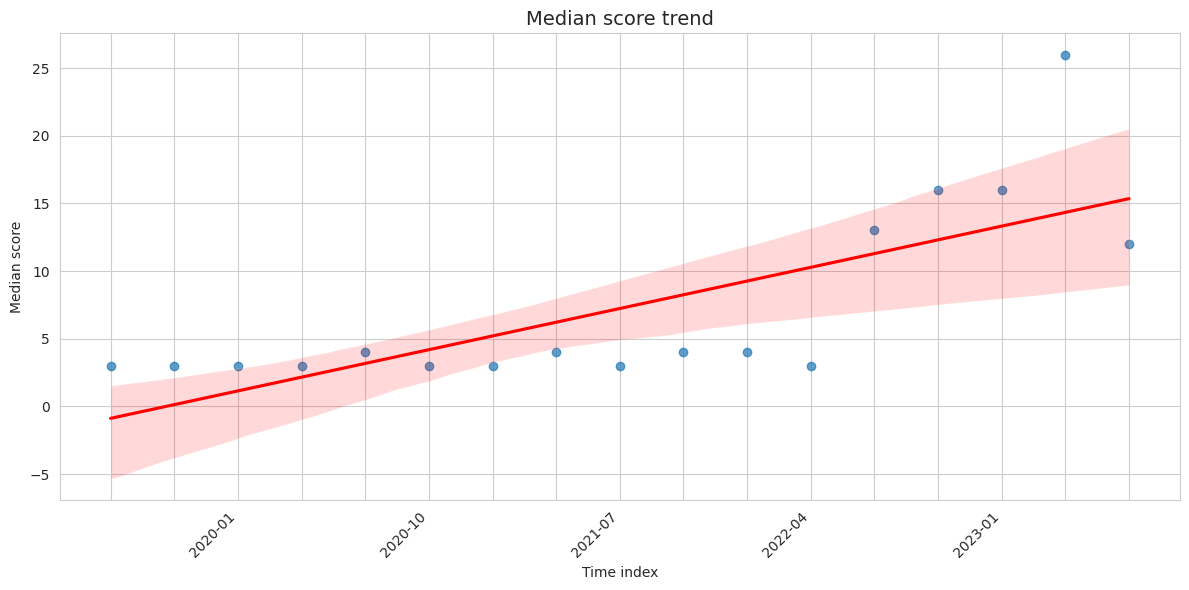

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.set_style("whitegrid")

sns.regplot(
    data=monthly_engagement,
    x='time_index',
    y='median_score',
    ax=ax,
    line_kws={"color": "red"},
    scatter_kws={"alpha": 0.7}
)

ax.set_title('Median score trend', fontsize=14)
ax.set_ylabel('Median score')
ax.set_xlabel('Time index')

month_labels = monthly_engagement['month'].astype(str)
ax.set_xticks(monthly_engagement['time_index'])
ax.set_xticklabels(month_labels, rotation=45, ha='right')

for i, label in enumerate(ax.get_xticklabels()):
    if (i + 1) % 3 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:**

For posts that managed to get any attention (score>1), the typical level of upvotes is growing by about one upvote every month over the study period. This suggests the topic is becoming more visible and popular. It is confirmed by statistical value and showed on plot.

#4. Summer months comparison between 2019 and 2024

In [ ]:
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [ ]:
def preprocess_comments(df):

    print(f"  Starting preprocessing with {len(df):,} rows")

    df_clean = df.copy()

    text_col = 'body' if 'body' in df_clean.columns else 'text'
    df_clean = df_clean.dropna(subset=[text_col]).copy()

    if 'author' in df_clean.columns and 'created' in df_clean.columns:
        df_clean = df_clean.drop_duplicates(subset=["author", text_col, "created"])

    df_clean[text_col] = df_clean[text_col].str.lower()

    if 'author' in df_clean.columns:
        df_clean["author"] = df_clean["author"].str.strip()
        df_clean["author"] = df_clean["author"].str.replace(r"^u/", "", regex=True)

    df_clean[text_col] = (
        df_clean[text_col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)      # remove extra spaces/newlines
        .str.replace(r"[^a-zA-Z0-9\s'.,!?-]", "", regex=True)  # remove odd symbols
    )

    if 'link' in df_clean.columns:
        sub_pattern = r'(?i)(?:https?://)?(?:www\.|old\.|np\.)?reddit\.com/r/([^/?#]+)/?'
        extracted_sub = df_clean["link"].astype(str).str.extract(sub_pattern)[0]

        if 'subreddit' not in df_clean.columns:
            df_clean["subreddit"] = extracted_sub
        else:
            df_clean["subreddit"] = df_clean["subreddit"].fillna(extracted_sub)

    print(f"Preprocessing complete: {len(df_clean):,} rows")
    return df_clean

In [ ]:
def load_monthly_data(base_path, data_type, months, year):
    dfs = []
    month_names = {6: 'Jun', 7: 'Jul', 8: 'Aug'}

    for month in months:
        if data_type == 'submissions':
            file_path = f"{base_path}/{data_type}/cleaned_RS_{year}-{month:02d}.csv"
        else:  # comments
            file_path = f"{base_path}/{data_type}/RC_{year}-{month:02d}.csv"

        print(f"Loading {month_names[month]} {year} {data_type}...")

        df = pd.read_csv(file_path)
        df['month'] = month
        df['year'] = year
        df['month_name'] = month_names[month]
        dfs.append(df)

    if dfs:
        combined = pd.concat(dfs, ignore_index=True)
        print(f"\nTotal {data_type} for {year}: {len(combined):,} rows")

        if data_type == 'comments':
            combined = preprocess_comments(combined)

        return combined
    return None

In [ ]:
base_path = "/content/drive/MyDrive/reddit datasets team 7"
months = [6, 7, 8]  # June, July, August

submissions_2019 = load_monthly_data(base_path, 'submissions', months, 2019)

submissions_2024 = load_monthly_data(base_path, 'submissions', months, 2024)

comments_2019 = load_monthly_data(base_path, 'comments', months, 2019)

comments_2024 = load_monthly_data(base_path, 'comments', months, 2024)

Loading Jun 2019 submissions...
Loading Jul 2019 submissions...
Loading Aug 2019 submissions...

Total submissions for 2019: 297,738 rows
Loading Jun 2024 submissions...
Loading Jul 2024 submissions...
Loading Aug 2024 submissions...

Total submissions for 2024: 254,924 rows
Loading Jun 2019 comments...
Loading Jul 2019 comments...
Loading Aug 2019 comments...

Total comments for 2019: 3,748,941 rows
  Starting preprocessing with 3,748,941 rows
Preprocessing complete: 3,370,481 rows
Loading Jun 2024 comments...
Loading Jul 2024 comments...
Loading Aug 2024 comments...

Total comments for 2024: 4,233,673 rows
  Starting preprocessing with 4,233,673 rows
Preprocessing complete: 3,990,822 rows


In [ ]:
comments_2019.rename(columns={'body': 'text'}, inplace=True)
comments_2024.rename(columns={'body': 'text'}, inplace=True)

In [ ]:
def filter_tradwife_content(df, text_columns):

    # Keywords related to tradwife topic
    keywords = [
        "tradwife", "traditional wife", "traditional woman", "traditional women", "tradwives", "housewives", "trad wife",
        "housewife", "stay at home wife", "stay at home mom", "domestic goddess",
        # roles and ideology terms
        "femininity", "submission", "gender role", "family first", "from scratch cooking",
        "homemaker", "family values", "conservative woman", "tradlife",
        "anti-feminist", "homekeeper", "nara aziza", "ballerina farm"
    ]

    pattern = '|'.join(keywords)

    mask = pd.Series([False] * len(df))
    for col in text_columns:
        if col in df.columns:
            mask |= df[col].astype(str).fillna('').str.contains(pattern, case=False, regex=True, na=False)

    filtered = df[mask].copy()
    print(f"Found {len(filtered):,} rows containing tradwife keywords")

    return filtered

print("\n2019 Submissions:")
sub_2019_tradwife = filter_tradwife_content(submissions_2019, ['title', 'text'])

print("\n2024 Submissions:")
sub_2024_tradwife = filter_tradwife_content(submissions_2024, ['title', 'text'])

def get_submission_ids(df):
    if df is None or len(df) == 0:
        return set()

    submission_ids = set()

    if 'link' in df.columns:
        for link in df['link'].dropna():
            # Extract submission ID from Reddit URL
            # Format: https://www.reddit.com/r/subreddit/comments/SUBMISSION_ID/...
            parts = str(link).split('/')
            if 'comments' in parts:
                idx = parts.index('comments')
                if idx + 1 < len(parts):
                    submission_ids.add(parts[idx + 1])

    print(f"  Extracted {len(submission_ids):,} unique submission IDs")
    return submission_ids

sub_ids_2019 = get_submission_ids(sub_2019_tradwife)
sub_ids_2024 = get_submission_ids(sub_2024_tradwife)


2019 Submissions:
Found 227 rows containing tradwife keywords

2024 Submissions:
Found 384 rows containing tradwife keywords
  Extracted 227 unique submission IDs
  Extracted 384 unique submission IDs


In [ ]:
def filter_comments_comprehensive(comments_df, submission_ids, year):

    comments_df_clean = comments_df.reset_index(drop=True)

    keyword_matches = filter_tradwife_content(comments_df_clean, ['text'])
    keyword_count = len(keyword_matches) if keyword_matches is not None else 0

    related_comments = pd.DataFrame()

    if len(submission_ids) > 0:
        if 'link' in comments_df_clean.columns:

            mask = comments_df_clean['link'].astype(str).apply(
                lambda x: any(sub_id in str(x) for sub_id in submission_ids)
            )

            related_comments = comments_df_clean[mask].copy()
            print(f"  Found {len(related_comments):,} comments related to tradwife submissions")

    if keyword_matches is not None and len(keyword_matches) > 0:
        if len(related_comments) > 0:
            combined = pd.concat([keyword_matches, related_comments]).drop_duplicates()
            print(f"  Total unique comments: {len(combined):,} (keyword: {keyword_count:,}, submission-related: {len(related_comments):,})")
            return combined
        else:
            return keyword_matches
    else:
        return related_comments if len(related_comments) > 0 else None

com_2019_tradwife = filter_comments_comprehensive(comments_2019, sub_ids_2019, 2019)

com_2024_tradwife = filter_comments_comprehensive(comments_2024, sub_ids_2024, 2024)

Found 21,833 rows containing tradwife keywords
  Found 2,637 comments related to tradwife submissions
  Total unique comments: 24,243 (keyword: 21,833, submission-related: 2,637)
Found 32,535 rows containing tradwife keywords
  Found 6,908 comments related to tradwife submissions
  Total unique comments: 38,922 (keyword: 32,535, submission-related: 6,908)


In [ ]:
EXCLUSION_BOTS = [
    "MobileModBot",
    "AutoModerator",
    "mobile_bot",
    "RemindMeBot",
    "TotesMessenger",
    "MobileLinkBot",
    "MobileHelperBot",
    "kaeorin"
]

def exclude_bots(df, bot_list):
    if df is None or 'author' not in df.columns or len(df) == 0:
        return df

    initial_count = len(df)
    df_filtered = df[~df['author'].isin(bot_list)].copy()
    removed_count = initial_count - len(df_filtered)

    print(f"  Removed {removed_count:,} bot comments.")
    print(f"  Remaining user comments: {len(df_filtered):,}")

    return df_filtered

com_2019_tradwife = exclude_bots(com_2019_tradwife, EXCLUSION_BOTS)
com_2024_tradwife = exclude_bots(com_2024_tradwife, EXCLUSION_BOTS)

  Removed 14,885 bot comments.
  Remaining user comments: 9,358
  Removed 18,016 bot comments.
  Remaining user comments: 20,906



Submissions change: +69.2%
Comments change: +123.4%


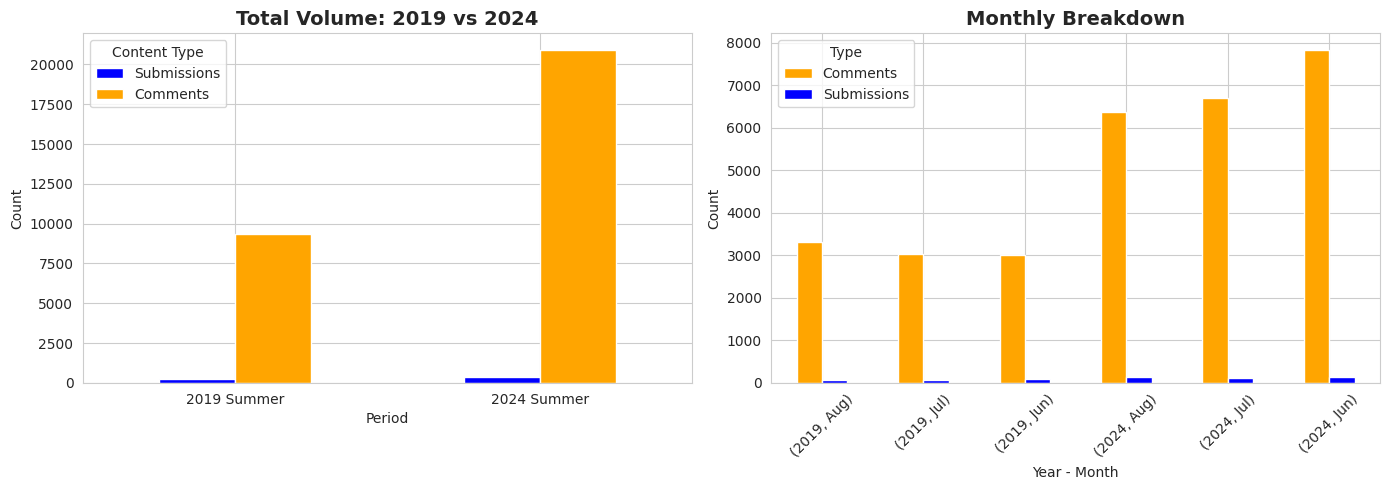

In [ ]:
volume_data = {
    'Period': ['2019 Summer', '2024 Summer'],
    'Submissions': [len(sub_2019_tradwife) if sub_2019_tradwife is not None else 0,
                   len(sub_2024_tradwife) if sub_2024_tradwife is not None else 0],
    'Comments': [len(com_2019_tradwife) if com_2019_tradwife is not None else 0,
                len(com_2024_tradwife) if com_2024_tradwife is not None else 0]
}
volume_df = pd.DataFrame(volume_data)

# Calculate percentage change
sub_change = ((volume_df.loc[1, 'Submissions'] - volume_df.loc[0, 'Submissions']) /
              volume_df.loc[0, 'Submissions'] * 100) if volume_df.loc[0, 'Submissions'] > 0 else 0
com_change = ((volume_df.loc[1, 'Comments'] - volume_df.loc[0, 'Comments']) /
              volume_df.loc[0, 'Comments'] * 100) if volume_df.loc[0, 'Comments'] > 0 else 0

print(f"\nSubmissions change: {sub_change:+.1f}%")
print(f"Comments change: {com_change:+.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

volume_df.plot(x='Period', y=['Submissions', 'Comments'], kind='bar', ax=axes[0], color=['blue','orange'], rot=0)
axes[0].set_title('Total Volume: 2019 vs 2024', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend(title='Content Type')

monthly_data = []
for df, year, content_type in [
    (sub_2019_tradwife, 2019, 'Submissions'),
    (sub_2024_tradwife, 2024, 'Submissions'),
    (com_2019_tradwife, 2019, 'Comments'),
    (com_2024_tradwife, 2024, 'Comments')
]:
    if df is not None and len(df) > 0:
        counts = df.groupby('month_name').size()
        for month in ['Jun', 'Jul', 'Aug']:
            monthly_data.append({
                'Year': year,
                'Month': month,
                'Type': content_type,
                'Count': counts.get(month, 0)
            })

monthly_df = pd.DataFrame(monthly_data)
monthly_pivot = monthly_df.pivot_table(values='Count', index=['Year', 'Month'], columns='Type', fill_value=0)
monthly_pivot.plot(kind='bar', ax=axes[1], color=['orange','blue'], rot=45)
axes[1].set_title('Monthly Breakdown', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Year - Month')

plt.tight_layout()
plt.show()

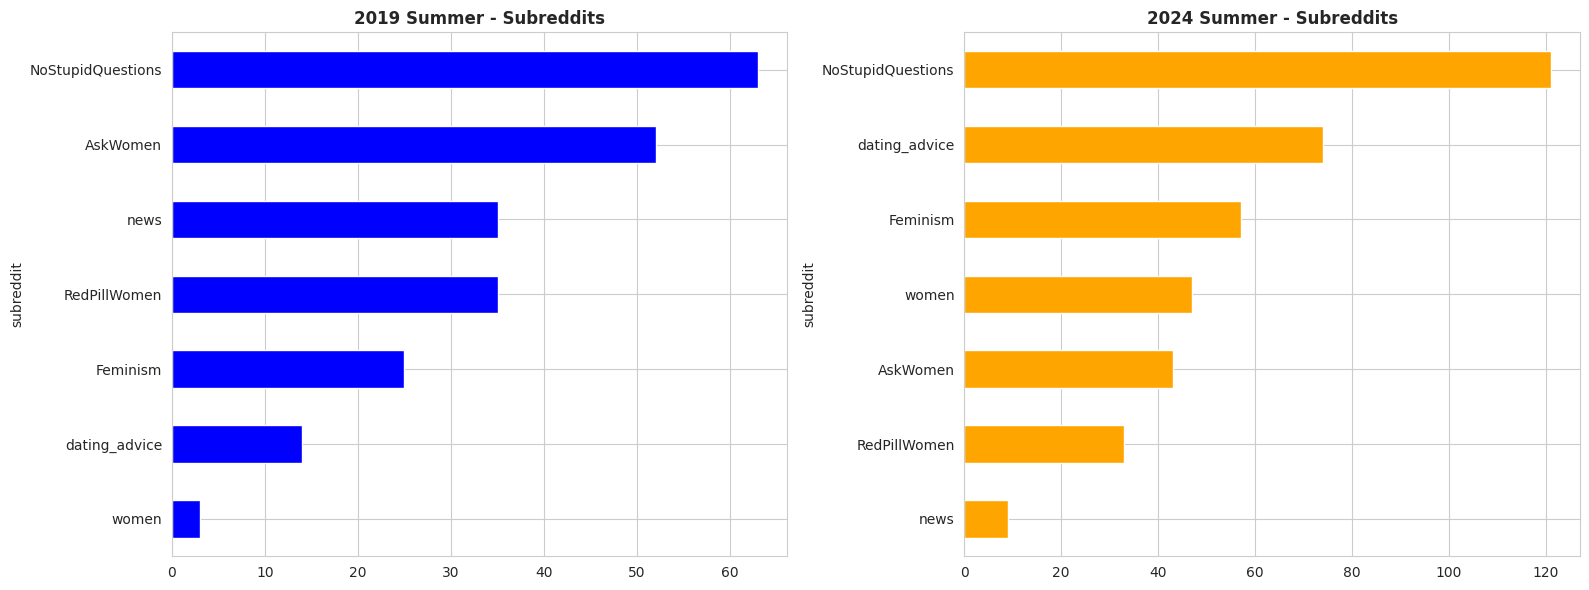

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if sub_2019_tradwife is not None and len(sub_2019_tradwife) > 0:
    subs_2019 = sub_2019_tradwife['subreddit'].value_counts()
    subs_2019.plot(kind='barh', ax=axes[0], color='blue')
    axes[0].set_title('2019 Summer - Subreddits', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()

if sub_2024_tradwife is not None and len(sub_2024_tradwife) > 0:
    subs_2024 = sub_2024_tradwife['subreddit'].value_counts()
    subs_2024.plot(kind='barh', ax=axes[1], color='orange')
    axes[1].set_title('2024 Summer - Subreddits', fontsize=12, fontweight='bold')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

The composition of the top contributing subreddits has changed: the volume from the most active source (r/NoStupidQuestions) nearly doubled (from ~60 to ~120 posts), and high-ranking subreddits shifted from general forums (r/news, r/AskWomen) in 2019 toward those centered on relationships and gender issues (r/dating_advice, r/Feminism) in 2024 .

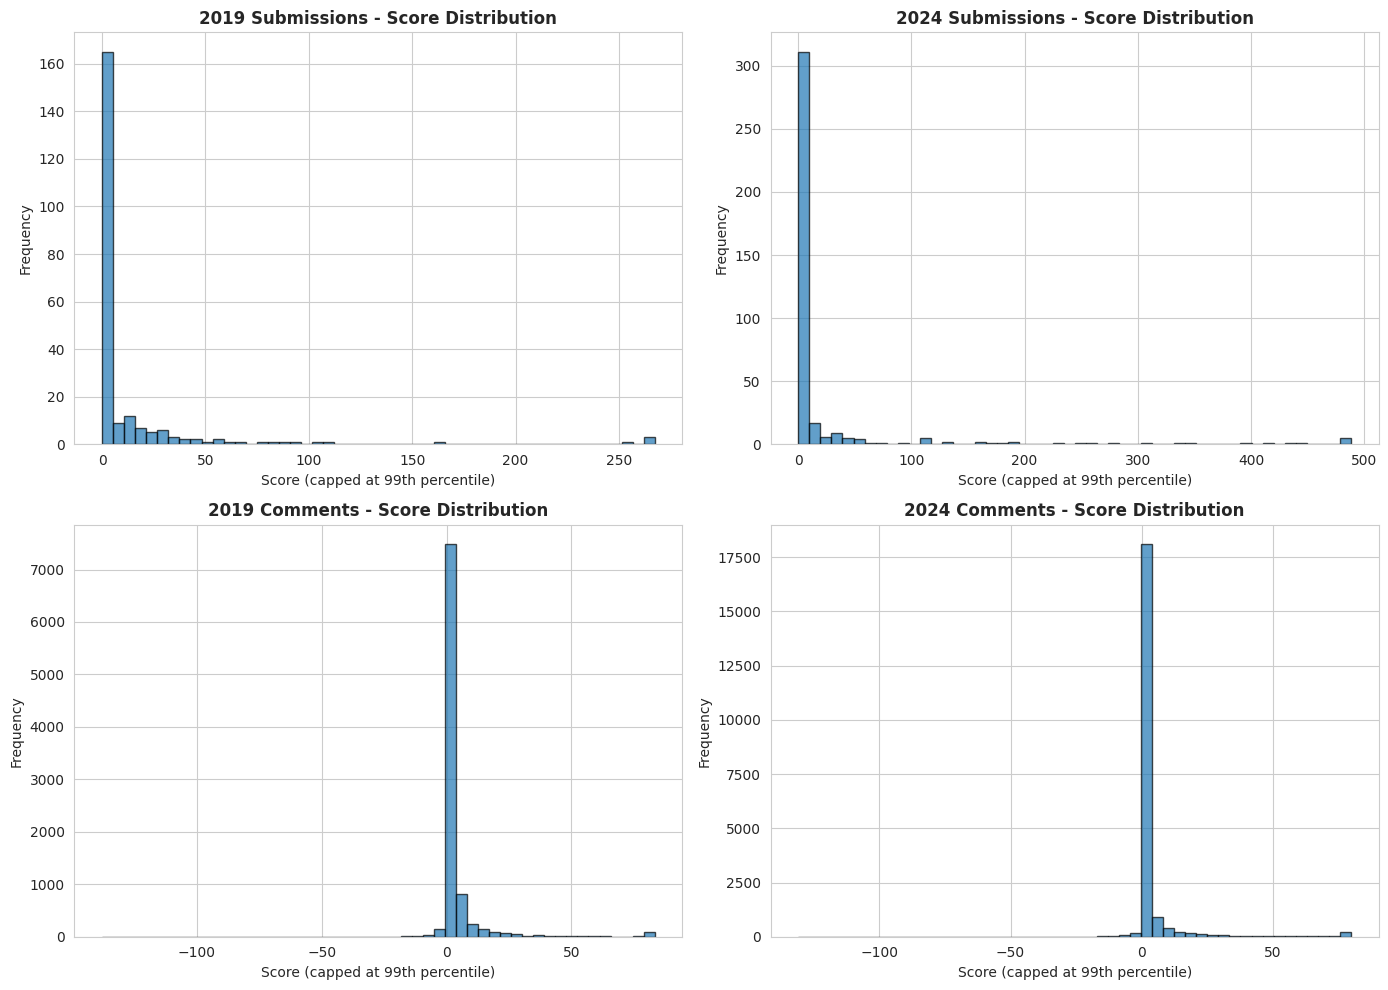

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (df, year, content_type, ax) in enumerate([
    (sub_2019_tradwife, 2019, 'Submissions', axes[0, 0]),
    (sub_2024_tradwife, 2024, 'Submissions', axes[0, 1]),
    (com_2019_tradwife, 2019, 'Comments', axes[1, 0]),
    (com_2024_tradwife, 2024, 'Comments', axes[1, 1])
]):
    if df is not None and len(df) > 0 and 'score' in df.columns:
        cap = df['score'].quantile(0.99)
        capped_scores = df['score'].clip(upper=cap)
        ax.hist(capped_scores, bins=50, edgecolor='black', alpha=0.7)
        ax.set_title(f'{year} {content_type} - Score Distribution', fontweight='bold')
        ax.set_xlabel('Score (capped at 99th percentile)')
        ax.set_ylabel('Frequency')
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{year} {content_type}')

plt.tight_layout()
plt.show()

Overall, the data suggests that while the platform's activity and score magnitudes may have increased significantly from 2019 to 2024 (as seen in the higher frequencies on the y-axes), the fundamental, highly-skewed scoring patterns for both submissions and comments have remained consistent.

In [ ]:
def plot_subreddit_distribution(com_2019, com_2024, type):
    df_2019 = com_2019.copy()
    df_2024 = com_2024.copy()
    df_2019['period'] = '2019 Summer'
    df_2024['period'] = '2024 Summer'

    df_2019 = df_2019[df_2019['subreddit'].astype(str).str.len() > 0]
    df_2024 = df_2024[df_2024['subreddit'].astype(str).str.len() > 0]

    combined_df = pd.concat([df_2019, df_2024]).reset_index(drop=True)

    subreddits = combined_df['subreddit'].value_counts().index.tolist()

    def categorize_subreddit(sub):
        return sub if sub in subreddits else 'Other'

    combined_df['subreddit_category'] = combined_df['subreddit'].apply(categorize_subreddit)

    counts = combined_df.groupby(['period', 'subreddit_category']).size().reset_index(name='count')

    total_counts = combined_df.groupby('period').size().reset_index(name='total')

    counts = pd.merge(counts, total_counts, on='period')

    counts['percentage'] = (counts['count'] / counts['total']) * 100

    plot_df = counts.pivot(index='period', columns='subreddit_category', values='percentage').fillna(0)

    column_order = [sub for sub in subreddits if sub in plot_df.columns]
    if 'Other' in plot_df.columns:
        column_order.append(column_order.pop(column_order.index('Other')))

    plot_df = plot_df[column_order]

    plt.figure(figsize=(12, 8))

    ax = plot_df.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 8),
        colormap='Spectral',
        edgecolor='black',
        linewidth=0.5,
        ax=plt.gca()
    )

    plt.title(f'Shift in Tradwife Discussion Venue: Subreddit Distribution for {type}', fontsize=16, fontweight='bold')
    plt.ylabel(f'Percentage of Total Related {type} (%)')
    plt.xlabel('')
    plt.xticks(rotation=0)
    plt.legend(title='Subreddit', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

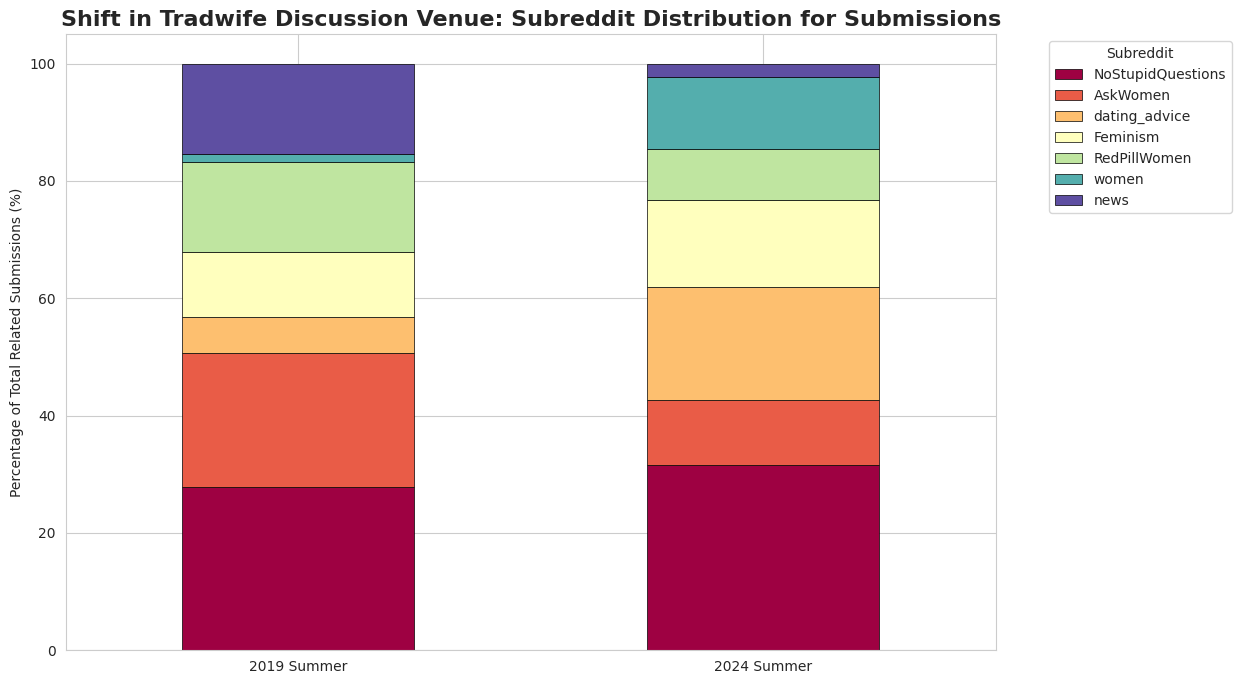

In [ ]:
plot_subreddit_distribution(sub_2019_tradwife, sub_2024_tradwife, type="Submissions")

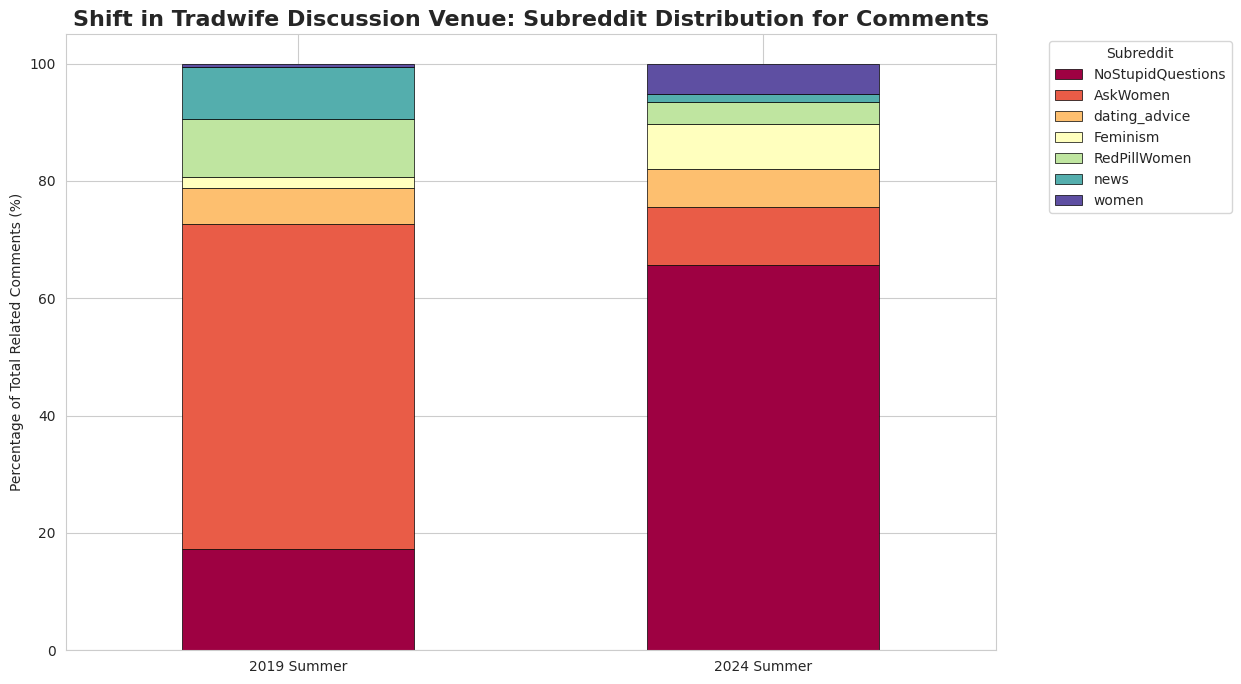

In [ ]:
plot_subreddit_distribution(com_2019_tradwife, com_2024_tradwife, type='Comments')

The two stacked bar charts clearly depict a significant shift in the discussion venue for the "Tradwife" topic between Summer 2019 and Summer 2024. For submissions, the proportion originating in the general subreddit "NoStupidQuestions" increased, showing the topic's migration toward broader forums. This trend is far more pronounced in comments, where "NoStupidQuestions" became overwhelmingly dominant by 2024, absorbing engagement that was previously concentrated in more specific communities like "AskWomen". Overall, the data illustrates the "Tradwife" discussion moving from specialized, gender-focused subreddits to a general, high-traffic platform.

Calculating engagement metrics...
2019 Submissions: Mean score = 21.00
2024 Submissions: Mean score = 29.50
2019 Comments: Mean score = 6.19
2024 Comments: Mean score = 5.32


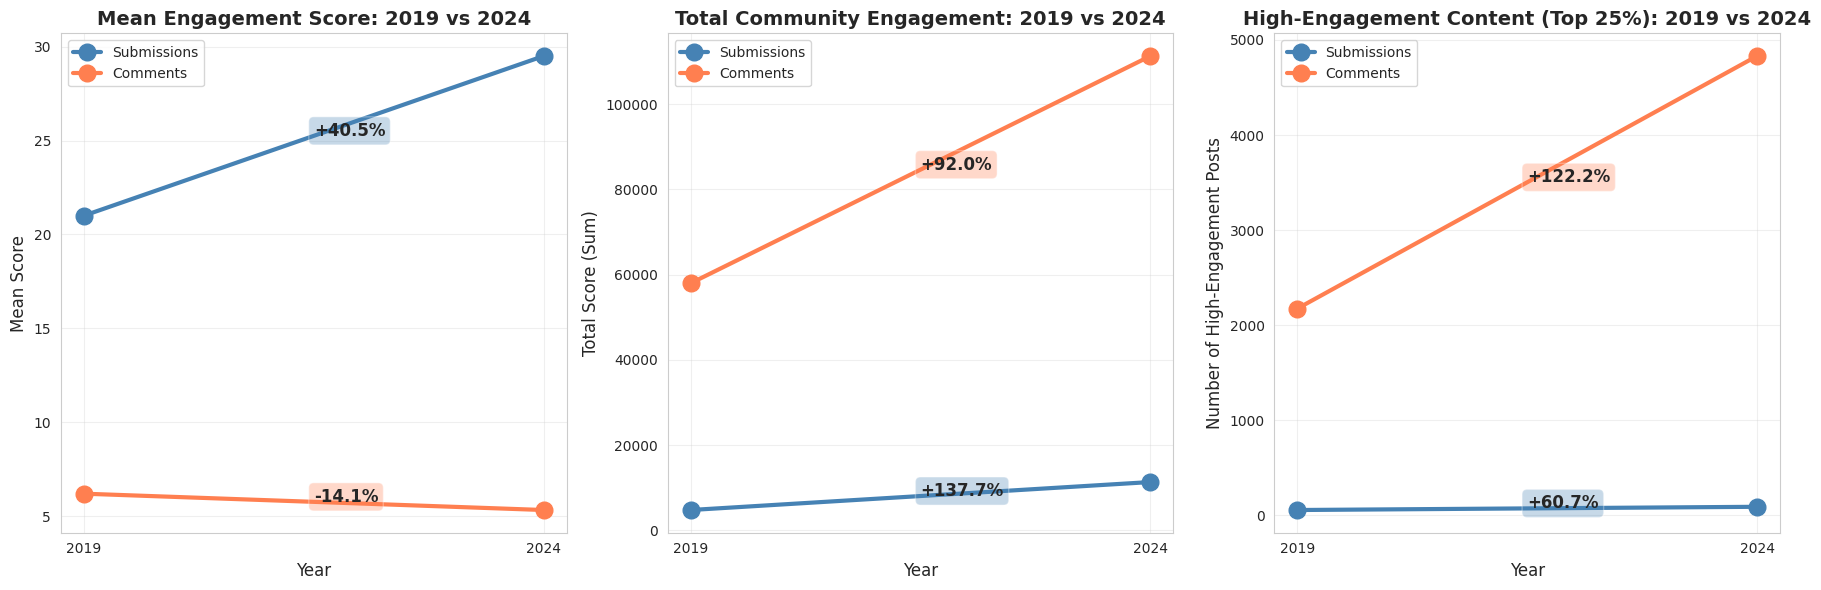

In [ ]:
def calculate_engagement_metrics(df, year, content_type):
    if df is None or len(df) == 0 or 'score' not in df.columns:
        return None

    metrics = {
        'year': year,
        'content_type': content_type,
        'total_posts': len(df),
        'mean_score': df['score'].mean(),
        'total_score': df['score'].sum(),
        'score_75th': df['score'].quantile(0.75),
        'score_90th': df['score'].quantile(0.90),
        'max_score': df['score'].max(),
        'high_engagement_posts': len(df[df['score'] > df['score'].quantile(0.75)])
    }

    return metrics

print("Calculating engagement metrics...")

metrics_list = []

data_sets = [
    (sub_2019_tradwife, 2019, 'Submissions'),
    (sub_2024_tradwife, 2024, 'Submissions'),
    (com_2019_tradwife, 2019, 'Comments'),
    (com_2024_tradwife, 2024, 'Comments')
]

for df, year, ctype in data_sets:
    m = calculate_engagement_metrics(df, year, ctype)
    if m:
        metrics_list.append(m)
        print(f"{year} {ctype}: Mean score = {m['mean_score']:.2f}")

metrics_df = pd.DataFrame(metrics_list)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_specs = [
    ('mean_score', 'Mean Score', 'Mean Engagement Score: 2019 vs 2024', 0),
    ('total_score', 'Total Score (Sum)', 'Total Community Engagement: 2019 vs 2024', 1),
    ('high_engagement_posts', 'Number of High-Engagement Posts', 'High-Engagement Content (Top 25%): 2019 vs 2024', 2)
]

for metric, ylabel, title, col_idx in plot_specs:
    ax = axes[col_idx]

    for ctype, color in [('Submissions', 'steelblue'), ('Comments', 'coral')]:
        data = metrics_df[metrics_df['content_type'] == ctype]
        if len(data) == 2:
            years = data['year'].values
            scores = data[metric].values
            ax.plot(years, scores, marker='o', linewidth=3, markersize=12, label=ctype, color=color)

            pct_change = ((scores[1] - scores[0]) / scores[0]) * 100 if scores[0] != 0 else 0
            mid_x = (years[0] + years[1]) / 2
            mid_y = (scores[0] + scores[1]) / 2
            ax.annotate(f'{pct_change:+.1f}%', xy=(mid_x, mid_y), fontsize=12, fontweight='bold',
                        bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks([2019, 2024])

plt.tight_layout()
plt.show()

This analysis of engagement metrics from 2019 to 2024 reveals a significant and contrasting trend between submissions and comments. While the mean score for submissions increased by +40.5% (from 21.00 to 29.50), the mean score for comments decreased by -14.1% (from 6.19 to 5.32). However, the Total Community Engagement (Sum of Scores) shows explosive growth for both, with comments seeing an immense +82.0% increase and submissions rising by +137.7%, indicating a massive increase in overall activity and scoring volume. This increase in volume is further emphasized by the High-Engagement Content chart, which shows the number of high-scoring posts rising significantly for both submissions (+60.7%) and comments (+122.2%), suggesting a substantial growth in popular content.

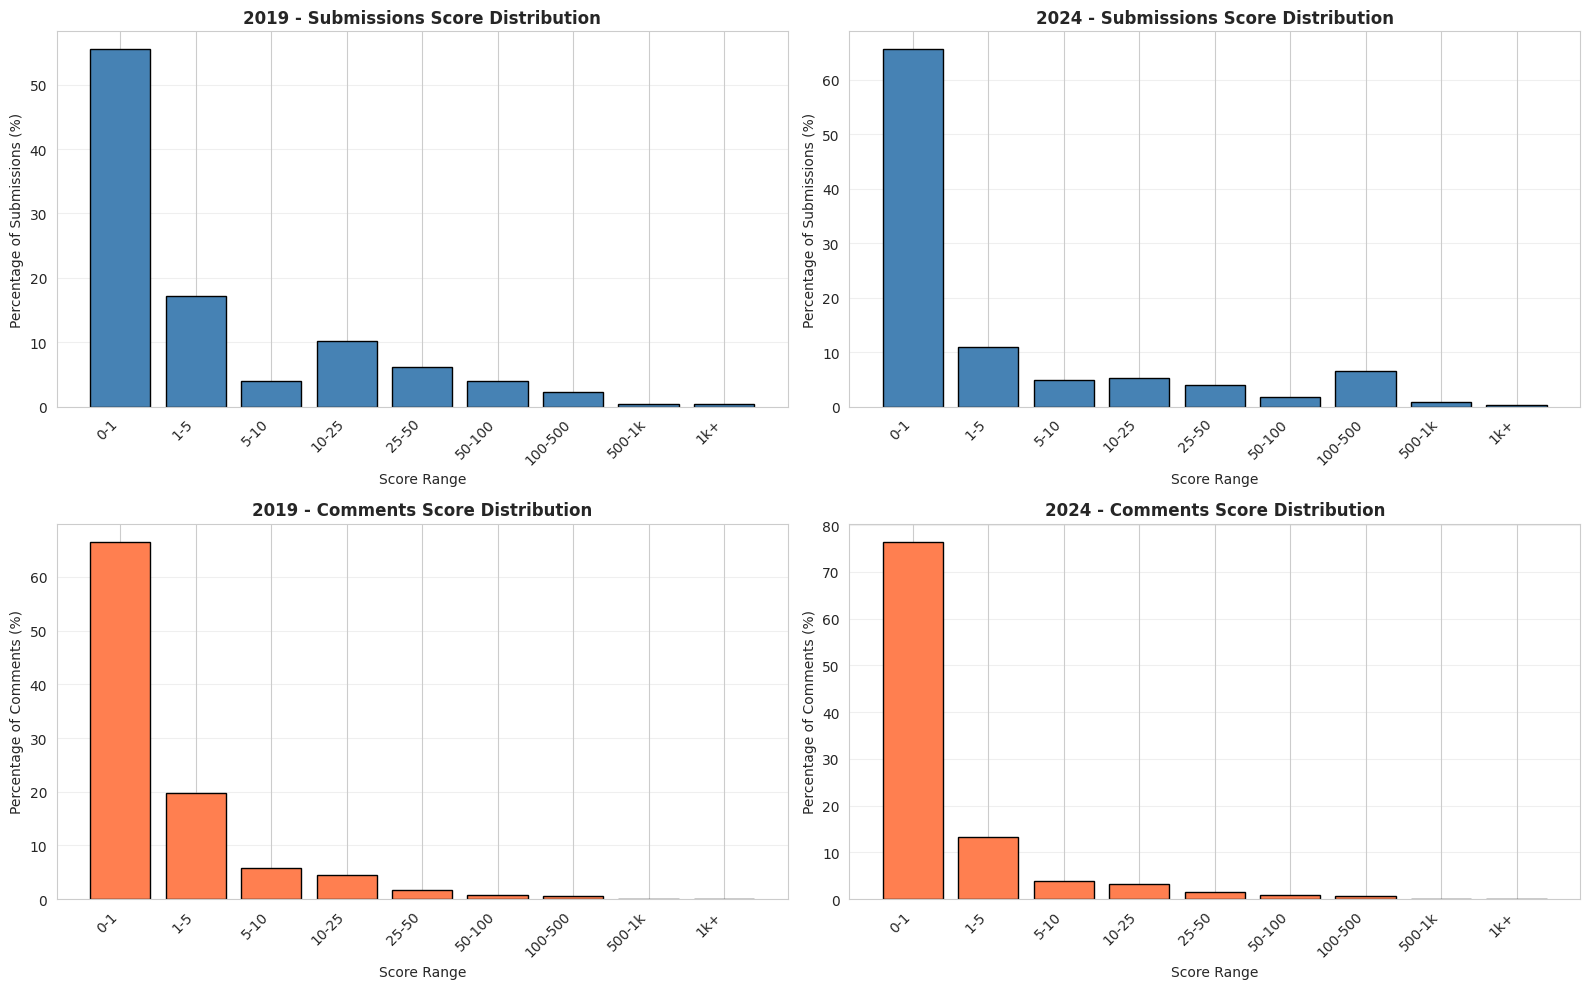

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

dist_data = [
    (sub_2019_tradwife, 2019, axes[0, 0], 'Submissions', 'steelblue'),
    (sub_2024_tradwife, 2024, axes[0, 1], 'Submissions', 'steelblue'),
    (com_2019_tradwife, 2019, axes[1, 0], 'Comments', 'coral'),
    (com_2024_tradwife, 2024, axes[1, 1], 'Comments', 'coral')
]

for df, year, ax, ctype, color in dist_data:
    if df is not None and len(df) > 0 and 'score' in df.columns:
        bins = [0, 1, 5, 10, 25, 50, 100, 500, 1000, df['score'].max()]
        labels = ['0-1', '1-5', '5-10', '10-25', '25-50', '50-100', '100-500', '500-1k', '1k+']

        df_temp = df.copy()
        df_temp['score_bin'] = pd.cut(df_temp['score'], bins=bins, labels=labels, include_lowest=True)

        counts = df_temp['score_bin'].value_counts().sort_index()
        percentages = (counts / counts.sum() * 100)

        ax.bar(range(len(percentages)), percentages.values, color=color, edgecolor='black')
        ax.set_xticks(range(len(percentages)))
        ax.set_xticklabels(percentages.index, rotation=45, ha='right')
        ax.set_xlabel('Score Range')
        ax.set_ylabel(f'Percentage of {ctype} (%)')
        ax.set_title(f'{year} - {ctype} Score Distribution', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

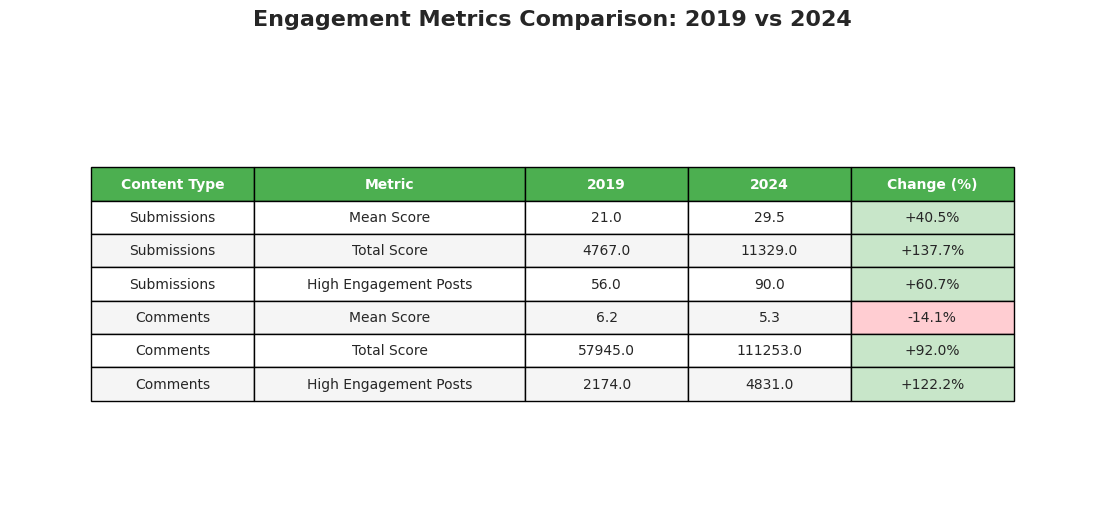

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

comparison_data = []
for ctype in ['Submissions', 'Comments']:
    data_2019 = metrics_df[(metrics_df['content_type'] == ctype) & (metrics_df['year'] == 2019)]
    data_2024 = metrics_df[(metrics_df['content_type'] == ctype) & (metrics_df['year'] == 2024)]

    if len(data_2019) > 0 and len(data_2024) > 0:
        for metric in ['mean_score', 'total_score', 'high_engagement_posts']:
            val_2019 = data_2019.iloc[0][metric]
            val_2024 = data_2024.iloc[0][metric]
            change = ((val_2024 - val_2019) / val_2019 * 100) if val_2019 > 0 else 0

            metric_name = metric.replace('_', ' ').title()
            comparison_data.append([
                ctype,
                metric_name,
                f'{val_2019:.1f}',
                f'{val_2024:.1f}',
                f'{change:+.1f}%'
            ])

table = ax.table(cellText=comparison_data,
                colLabels=['Content Type', 'Metric', '2019', '2024', 'Change (%)'],
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.25, 0.15, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(5):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(comparison_data) + 1):
    change_val = float(comparison_data[i-1][4].rstrip('%'))
    if change_val > 0:
        table[(i, 4)].set_facecolor('#c8e6c9')
    elif change_val < 0:
        table[(i, 4)].set_facecolor('#ffcdd2')

    if i % 2 == 0:
        for j in range(4):
            table[(i, j)].set_facecolor('#f5f5f5')

plt.title('Engagement Metrics Comparison: 2019 vs 2024',
          fontsize=16, fontweight='bold', pad=20)
plt.show()

All metrics related to volume (Total Score and High Engagement Posts) showed explosive growth, particularly comments, which saw a +92.0% increase in Total Score and a +122.2% increase in high-engagement posts. However, while the Mean Score for Submissions increased by +40.5%, suggesting higher quality posts on average, the Mean Score for Comments decreased by -14.1%, indicating that the massive increase in comment volume may have led to a proportional decrease in the average score or quality of individual comments.

In [ ]:
for ctype in ['Submissions', 'Comments']:
    print(f"\n{ctype}:")
    data_2019 = metrics_df[(metrics_df['content_type'] == ctype) & (metrics_df['year'] == 2019)]
    data_2024 = metrics_df[(metrics_df['content_type'] == ctype) & (metrics_df['year'] == 2024)]

    if len(data_2019) > 0 and len(data_2024) > 0:
        mean_2019 = data_2019.iloc[0]['mean_score']
        mean_2024 = data_2024.iloc[0]['mean_score']
        mean_change = ((mean_2024 - mean_2019) / mean_2019 * 100)

        total_2019 = data_2019.iloc[0]['total_score']
        total_2024 = data_2024.iloc[0]['total_score']
        total_change = ((total_2024 - total_2019) / total_2019 * 100)

        print(f"  Mean Score: {mean_2019:.1f} → {mean_2024:.1f} ({mean_change:+.1f}%)")
        print(f"  Total Engagement: {total_2019:.0f} → {total_2024:.0f} ({total_change:+.1f}%)")


Submissions:
  Mean Score: 21.0 → 29.5 (+40.5%)
  Total Engagement: 4767 → 11329 (+137.7%)

Comments:
  Mean Score: 6.2 → 5.3 (-14.1%)
  Total Engagement: 57945 → 111253 (+92.0%)


In [ ]:
def prepare_daily_data(tradwife_subs, all_subs, year):
    if 'created' in all_subs.columns:
        all_subs = all_subs.copy()
        tradwife_subs = tradwife_subs.copy()
        all_subs['date'] = pd.to_datetime(all_subs['created'], errors='coerce')
        tradwife_subs['date'] = pd.to_datetime(tradwife_subs['created'], errors='coerce')
        all_subs['date'] = all_subs['date'].dt.date
        tradwife_subs['date'] = tradwife_subs['date'].dt.date
        total_daily = all_subs.groupby('date').size().reset_index(name='total_submissions')
        tradwife_daily = tradwife_subs.groupby('date').size().reset_index(name='tradwife_submissions')
        daily_data = pd.merge(total_daily, tradwife_daily, on='date', how='left')
        daily_data['tradwife_submissions'] = daily_data['tradwife_submissions'].fillna(0)
        daily_data['ratio_pct'] = (daily_data['tradwife_submissions'] / daily_data['total_submissions']) * 100
        daily_data['year'] = year
        daily_data['date'] = pd.to_datetime(daily_data['date'])
        daily_data['month'] = daily_data['date'].dt.month
        daily_data['month_name'] = daily_data['date'].dt.strftime('%B')

        return daily_data
    else:
        print(f"Warning: No 'created' column found for {year}")
        return None

daily_2019 = prepare_daily_data(sub_2019_tradwife, submissions_2019, 2019)
daily_2024 = prepare_daily_data(sub_2024_tradwife, submissions_2024, 2024)

if daily_2019 is not None:
    print(f"\n2019 Summary:")
    print(f"  Date range: {daily_2019['date'].min()} to {daily_2019['date'].max()}")
    print(f"  Average tradwife submissions per day: {daily_2019['tradwife_submissions'].mean():.1f}")
    print(f"  Average total submissions per day: {daily_2019['total_submissions'].mean():.1f}")
    print(f"  Average ratio: {daily_2019['ratio_pct'].mean():.4f}%")

if daily_2024 is not None:
    print(f"\n2024 Summary:")
    print(f"  Date range: {daily_2024['date'].min()} to {daily_2024['date'].max()}")
    print(f"  Average tradwife submissions per day: {daily_2024['tradwife_submissions'].mean():.1f}")
    print(f"  Average total submissions per day: {daily_2024['total_submissions'].mean():.1f}")
    print(f"  Average ratio: {daily_2024['ratio_pct'].mean():.4f}%")


2019 Summary:
  Date range: 2019-06-01 00:00:00 to 2019-09-01 00:00:00
  Average tradwife submissions per day: 2.4
  Average total submissions per day: 3201.5
  Average ratio: 0.0765%

2024 Summary:
  Date range: 2024-06-01 00:00:00 to 2024-09-01 00:00:00
  Average tradwife submissions per day: 4.1
  Average total submissions per day: 2741.1
  Average ratio: 0.1526%


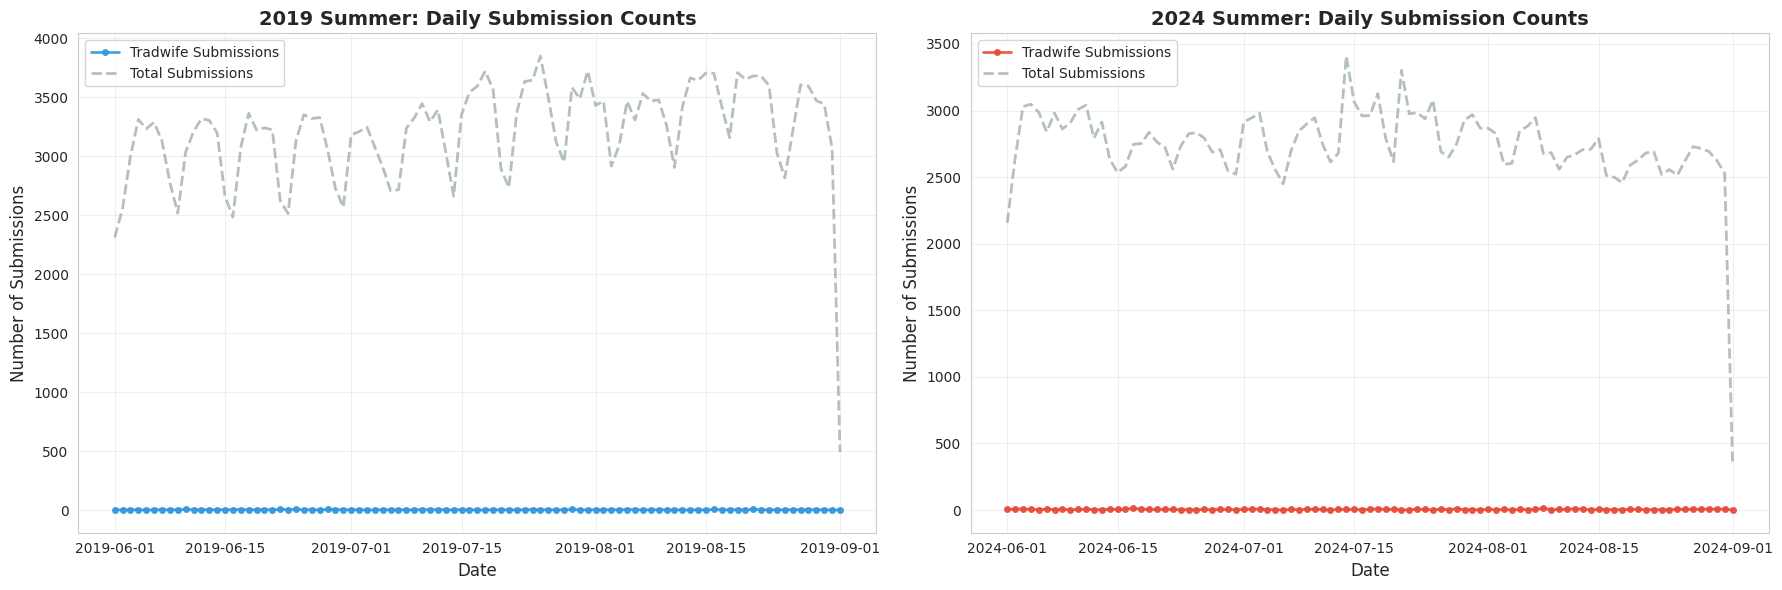

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
if daily_2019 is not None:
    ax.plot(daily_2019['date'], daily_2019['tradwife_submissions'],
            label='Tradwife Submissions', color='#3498db', linewidth=2, marker='o', markersize=4, alpha=0.9)
    ax.plot(daily_2019['date'], daily_2019['total_submissions'],
            label='Total Submissions', color='#95a5a6', linewidth=2, linestyle='--', alpha=0.7)

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Number of Submissions', fontsize=12)
    ax.set_title('2019 Summer: Daily Submission Counts', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

ax = axes[1]
if daily_2024 is not None:
    ax.plot(daily_2024['date'], daily_2024['tradwife_submissions'],
            label='Tradwife Submissions', color='#e74c3c', linewidth=2, marker='o', markersize=4, alpha=0.9)
    ax.plot(daily_2024['date'], daily_2024['total_submissions'],
            label='Total Submissions', color='#95a5a6', linewidth=2, linestyle='--', alpha=0.7)

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Number of Submissions', fontsize=12)
    ax.set_title('2024 Summer: Daily Submission Counts', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

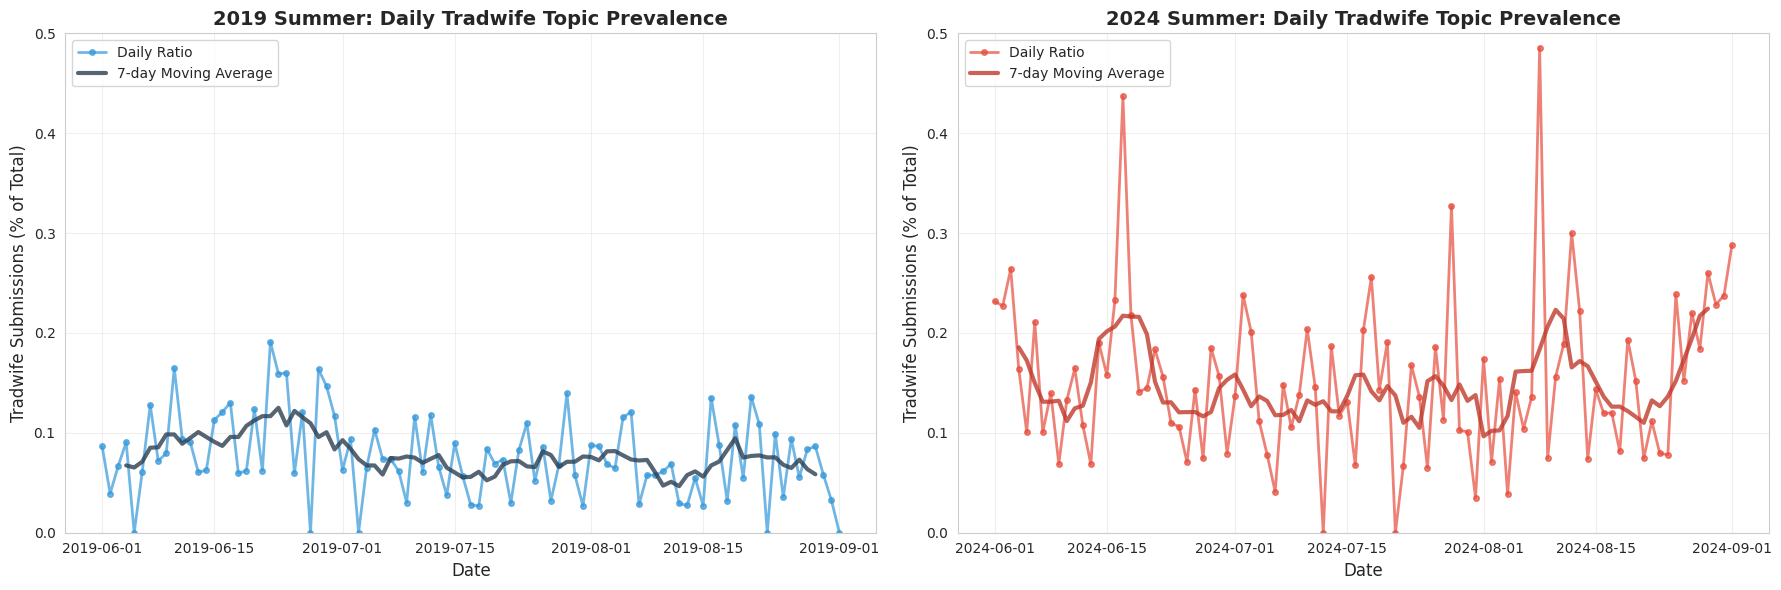

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
if daily_2019 is not None:
    ax.plot(daily_2019['date'], daily_2019['ratio_pct'],
            label='Daily Ratio', color='#3498db', linewidth=2, marker='o', markersize=4, alpha=0.7)
    ma_2019 = daily_2019['ratio_pct'].rolling(window=7, center=True).mean()
    ax.plot(daily_2019['date'], ma_2019,
            label='7-day Moving Average', color='#2c3e50', linewidth=3, alpha=0.8)

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Tradwife Submissions (% of Total)', fontsize=12)
    ax.set_title('2019 Summer: Daily Tradwife Topic Prevalence', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0,0.5)

ax = axes[1]
if daily_2024 is not None:
    ax.plot(daily_2024['date'], daily_2024['ratio_pct'],
            label='Daily Ratio', color='#e74c3c', linewidth=2, marker='o', markersize=4, alpha=0.7)
    ma_2024 = daily_2024['ratio_pct'].rolling(window=7, center=True).mean()
    ax.plot(daily_2024['date'], ma_2024,
            label='7-day Moving Average', color='#c0392b', linewidth=3, alpha=0.8)

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Tradwife Submissions (% of Total)', fontsize=12)
    ax.set_title('2024 Summer: Daily Tradwife Topic Prevalence', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0,0.5)

plt.tight_layout()
plt.show()

Comparing the daily prevalence of "Tradwife" submissions between 2019 and 2024 reveals a distinct change in topic dynamics. In 2019, the daily ratio generally hovered around $0.05\%$ to $0.15\%$ with relatively modest spikes. In 2024, however, the average prevalence appears higher, with the 7-day moving average fluctuating primarily between $0.1\%$ and $0.2\%$, showing a general increase in topic presence. Crucially, the 2024 data exhibits much more dramatic volatility, featuring pronounced, sharp spikes where the daily ratio temporarily reached nearly $0.5\%$, suggesting that the topic became subject to more sudden, intense bursts of community interest.

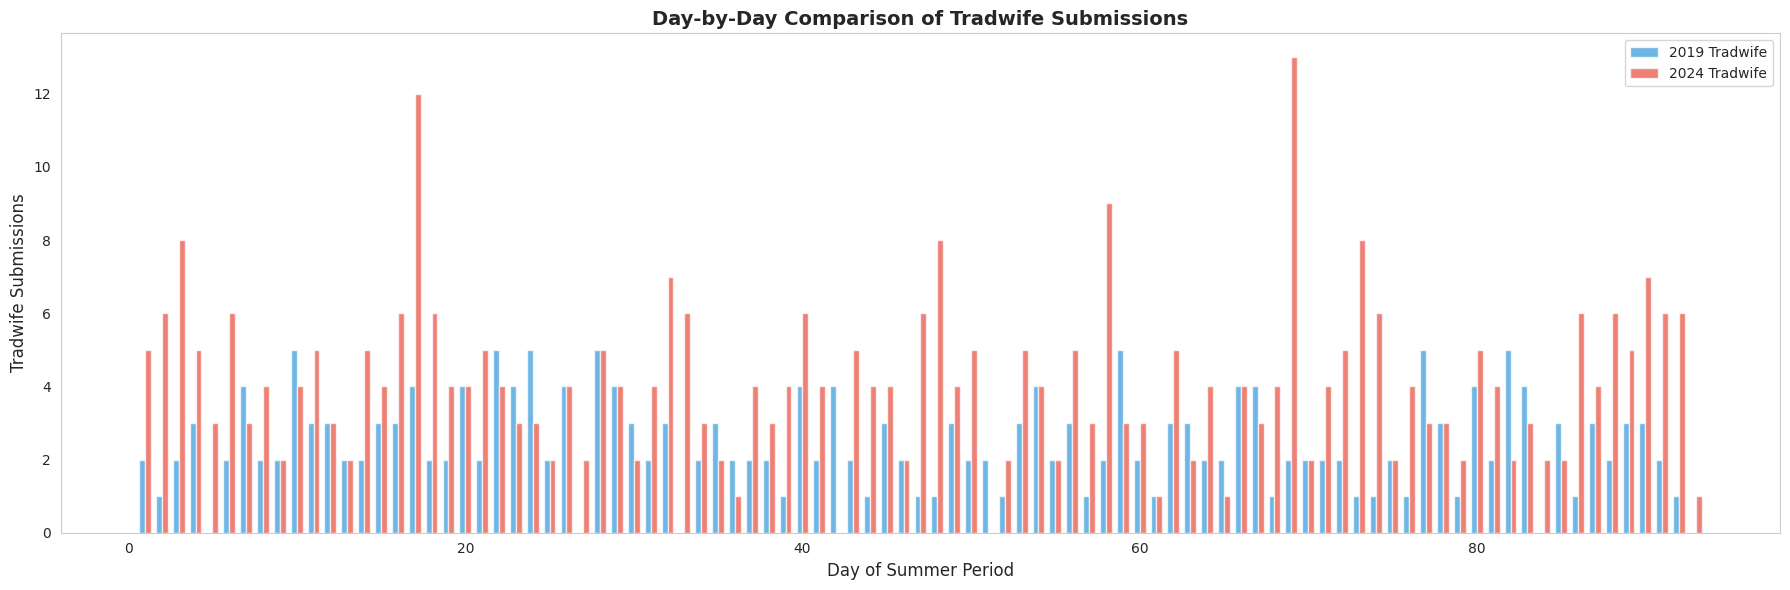

In [ ]:
fig, ax = plt.subplots(figsize=(18, 6))

if daily_2019 is not None and daily_2024 is not None:
    combined = pd.concat([daily_2019, daily_2024])
    combined['day_of_summer'] = combined.groupby('year').cumcount() + 1

    pivot_tradwife = combined.pivot(index='day_of_summer', columns='year', values='tradwife_submissions')
    pivot_total = combined.pivot(index='day_of_summer', columns='year', values='total_submissions')

    x = pivot_tradwife.index
    width = 0.35

    ax.bar(x - width/2, pivot_tradwife[2019], width, label='2019 Tradwife', color='#3498db', alpha=0.7)
    ax.bar(x + width/2, pivot_tradwife[2024], width, label='2024 Tradwife', color='#e74c3c', alpha=0.7)

    ax.set_xlabel('Day of Summer Period', fontsize=12)
    ax.set_ylabel('Tradwife Submissions', fontsize=12)
    ax.set_title('Day-by-Day Comparison of Tradwife Submissions', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(False)

plt.tight_layout()
plt.show()

While the 2019 data (blue bars) shows relatively consistent daily submission counts, rarely exceeding five per day, the 2024 data (red bars) is characterized by higher overall submission numbers. Crucially, 2024 exhibits several extreme peaks, with submissions reaching heights of 8, 9, and even 12 on certain days, which are levels not observed in the 2019 data. This disparity suggests the topic experienced significantly greater, more sporadic bursts of submission activity in 2024 compared to the more moderate daily flow of 2019.

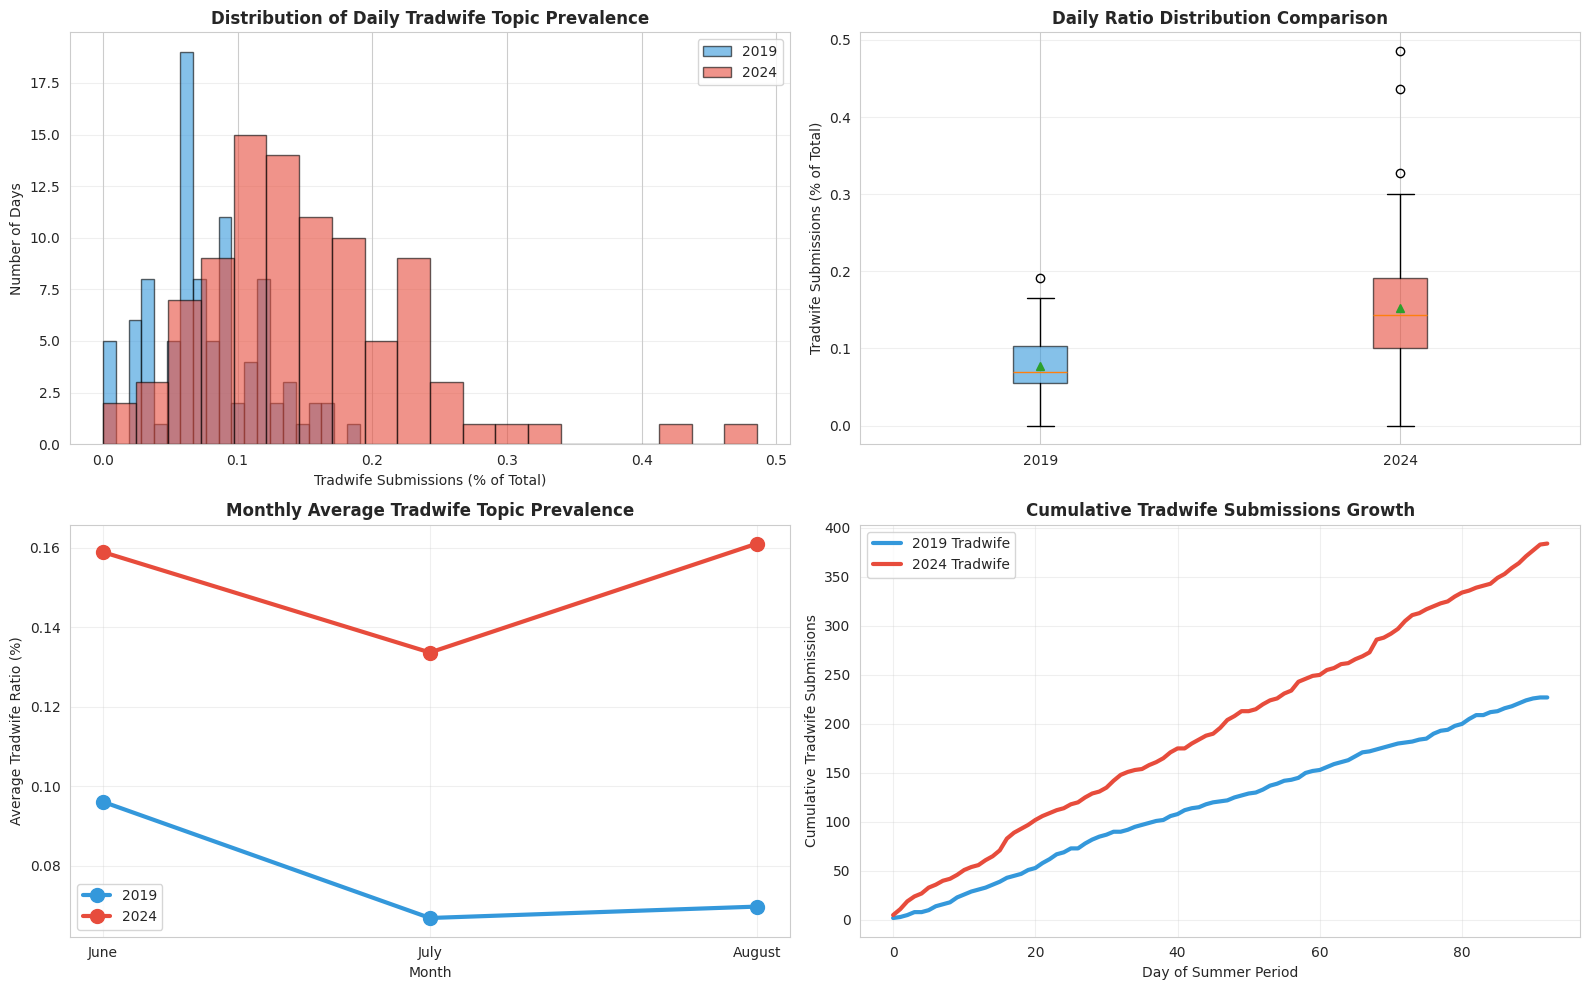

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Ratio Distribution (Histogram)
ax = axes[0, 0]

if daily_2019 is not None:
    ax.hist(daily_2019['ratio_pct'], bins=20, alpha=0.6, label='2019', color='#3498db', edgecolor='black')
if daily_2024 is not None:
    ax.hist(daily_2024['ratio_pct'], bins=20, alpha=0.6, label='2024', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Tradwife Submissions (% of Total)')
ax.set_ylabel('Number of Days')
ax.set_title('Distribution of Daily Tradwife Topic Prevalence', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Box Plot Comparison
ax = axes[0, 1]

box_data = []
labels = []

if daily_2019 is not None:
    box_data.append(daily_2019['ratio_pct'])
    labels.append('2019')
if daily_2024 is not None:
    box_data.append(daily_2024['ratio_pct'])
    labels.append('2024')

bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Tradwife Submissions (% of Total)')
ax.set_title('Daily Ratio Distribution Comparison', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Monthly Average Ratios
ax = axes[1, 0]

monthly_data = []
for df, year in [(daily_2019, 2019), (daily_2024, 2024)]:
    if df is not None:
        monthly = df.groupby('month_name').agg({
            'ratio_pct': 'mean',
            'tradwife_submissions': 'sum',
            'total_submissions': 'sum'
        }).reset_index()
        monthly['year'] = year
        monthly_data.append(monthly)

if monthly_data:
    monthly_combined = pd.concat(monthly_data)
    month_order = ['June', 'July', 'August']

    for year, color in [(2019, '#3498db'), (2024, '#e74c3c')]:
        data = monthly_combined[monthly_combined['year'] == year]
        data = data.set_index('month_name').reindex(month_order)
        ax.plot(range(len(month_order)), data['ratio_pct'],
                marker='o', linewidth=3, markersize=10, label=str(year), color=color)

    ax.set_xticks(range(len(month_order)))
    ax.set_xticklabels(month_order)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Tradwife Ratio (%)')
    ax.set_title('Monthly Average Tradwife Topic Prevalence', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot 4: Cumulative Comparison
ax = axes[1, 1]

if daily_2019 is not None:
    cumsum_2019 = daily_2019.sort_values('date')['tradwife_submissions'].cumsum()
    ax.plot(range(len(cumsum_2019)), cumsum_2019,
            label='2019 Tradwife', color='#3498db', linewidth=3)

if daily_2024 is not None:
    cumsum_2024 = daily_2024.sort_values('date')['tradwife_submissions'].cumsum()
    ax.plot(range(len(cumsum_2024)), cumsum_2024,
            label='2024 Tradwife', color='#e74c3c', linewidth=3)

ax.set_xlabel('Day of Summer Period')
ax.set_ylabel('Cumulative Tradwife Submissions')
ax.set_title('Cumulative Tradwife Submissions Growth', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The histogram shows the 2024 distribution shifted right, with higher prevalence days occurring more frequently, which is supported by the box plot showing the median daily ratio increasing from about $0.08\%$ in 2019 to around $0.15\%$ in 2024. Furthermore, the monthly average plot indicates that the 2024 prevalence remained consistently higher across the summer months, leading to a much steeper slope on the Cumulative Tradwife Submissions Growth chart, where total submissions nearly doubled from 2019 to 2024.

In [ ]:
if daily_2019 is not None and daily_2024 is not None:
    print(f"\n2019 Statistics:")
    print(f"  Average daily ratio: {daily_2019['ratio_pct'].mean():.4f}%")
    print(f"  Median daily ratio: {daily_2019['ratio_pct'].median():.4f}%")
    print(f"  Max daily ratio: {daily_2019['ratio_pct'].max():.4f}%")
    print(f"  Min daily ratio: {daily_2019['ratio_pct'].min():.4f}%")
    print(f"  Std deviation: {daily_2019['ratio_pct'].std():.4f}%")

    print(f"\n2024 Statistics:")
    print(f"  Average daily ratio: {daily_2024['ratio_pct'].mean():.4f}%")
    print(f"  Median daily ratio: {daily_2024['ratio_pct'].median():.4f}%")
    print(f"  Max daily ratio: {daily_2024['ratio_pct'].max():.4f}%")
    print(f"  Min daily ratio: {daily_2024['ratio_pct'].min():.4f}%")
    print(f"  Std deviation: {daily_2024['ratio_pct'].std():.4f}%")

    # Calculate change
    ratio_change = ((daily_2024['ratio_pct'].mean() - daily_2019['ratio_pct'].mean()) /
                    daily_2019['ratio_pct'].mean() * 100)

    print(f"\nKey Finding:")
    print(f"  Ratio change: {ratio_change:+.1f}%")


2019 Statistics:
  Average daily ratio: 0.0765%
  Median daily ratio: 0.0689%
  Max daily ratio: 0.1908%
  Min daily ratio: 0.0000%
  Std deviation: 0.0409%

2024 Statistics:
  Average daily ratio: 0.1526%
  Median daily ratio: 0.1433%
  Max daily ratio: 0.4856%
  Min daily ratio: 0.0000%
  Std deviation: 0.0807%

Key Finding:
  Ratio change: +99.4%


In [ ]:
from textblob import TextBlob

def calculate_sentiment(text):
    if pd.isna(text) or str(text).strip() in ['', 'deleted', 'removed', 'nan']:
        return None
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return None

def categorize_sentiment(score):
    if pd.isna(score):
        return 'Unknown'
    if score >= 0.1:
        return 'Positive'
    if score <= -0.1:
        return 'Negative'
    return 'Neutral'

def analyze_submission_sentiment(df, year):
    if df is None or len(df) == 0:
        print(f"No data for {year}")
        return None

    df_sentiment = df.copy()

    if 'title' in df_sentiment.columns:
        df_sentiment['title_sentiment'] = df_sentiment['title'].apply(calculate_sentiment)
        df_sentiment['title_category'] = df_sentiment['title_sentiment'].apply(categorize_sentiment)

    text_col = 'text' if 'text' in df_sentiment.columns else 'selftext'
    if text_col in df_sentiment.columns:
        df_sentiment['text_sentiment'] = df_sentiment[text_col].apply(calculate_sentiment)
        df_sentiment['text_category'] = df_sentiment['text_sentiment'].apply(categorize_sentiment)

    if 'title_sentiment' in df_sentiment.columns and 'text_sentiment' in df_sentiment.columns:
        df_sentiment['combined_sentiment'] = df_sentiment[['title_sentiment', 'text_sentiment']].mean(axis=1)
        df_sentiment['combined_category'] = df_sentiment['combined_sentiment'].apply(categorize_sentiment)
    return df_sentiment

sub_2019_sentiment = analyze_submission_sentiment(sub_2019_tradwife, 2019)
sub_2024_sentiment = analyze_submission_sentiment(sub_2024_tradwife, 2024)

def analyze_comment_sentiment(df, year):
    if df is None or len(df) == 0:
        print(f"No data for {year}")
        return None

    df_sentiment = df.copy()

    text_col = 'text' if 'text' in df_sentiment.columns else 'body'
    if text_col in df_sentiment.columns:
        df_sentiment['text_sentiment'] = df_sentiment[text_col].apply(calculate_sentiment)
        df_sentiment['text_category'] = df_sentiment['text_sentiment'].apply(categorize_sentiment)

    return df_sentiment

com_2019_sentiment = analyze_comment_sentiment(com_2019_tradwife, 2019)
com_2024_sentiment = analyze_comment_sentiment(com_2024_tradwife, 2024)

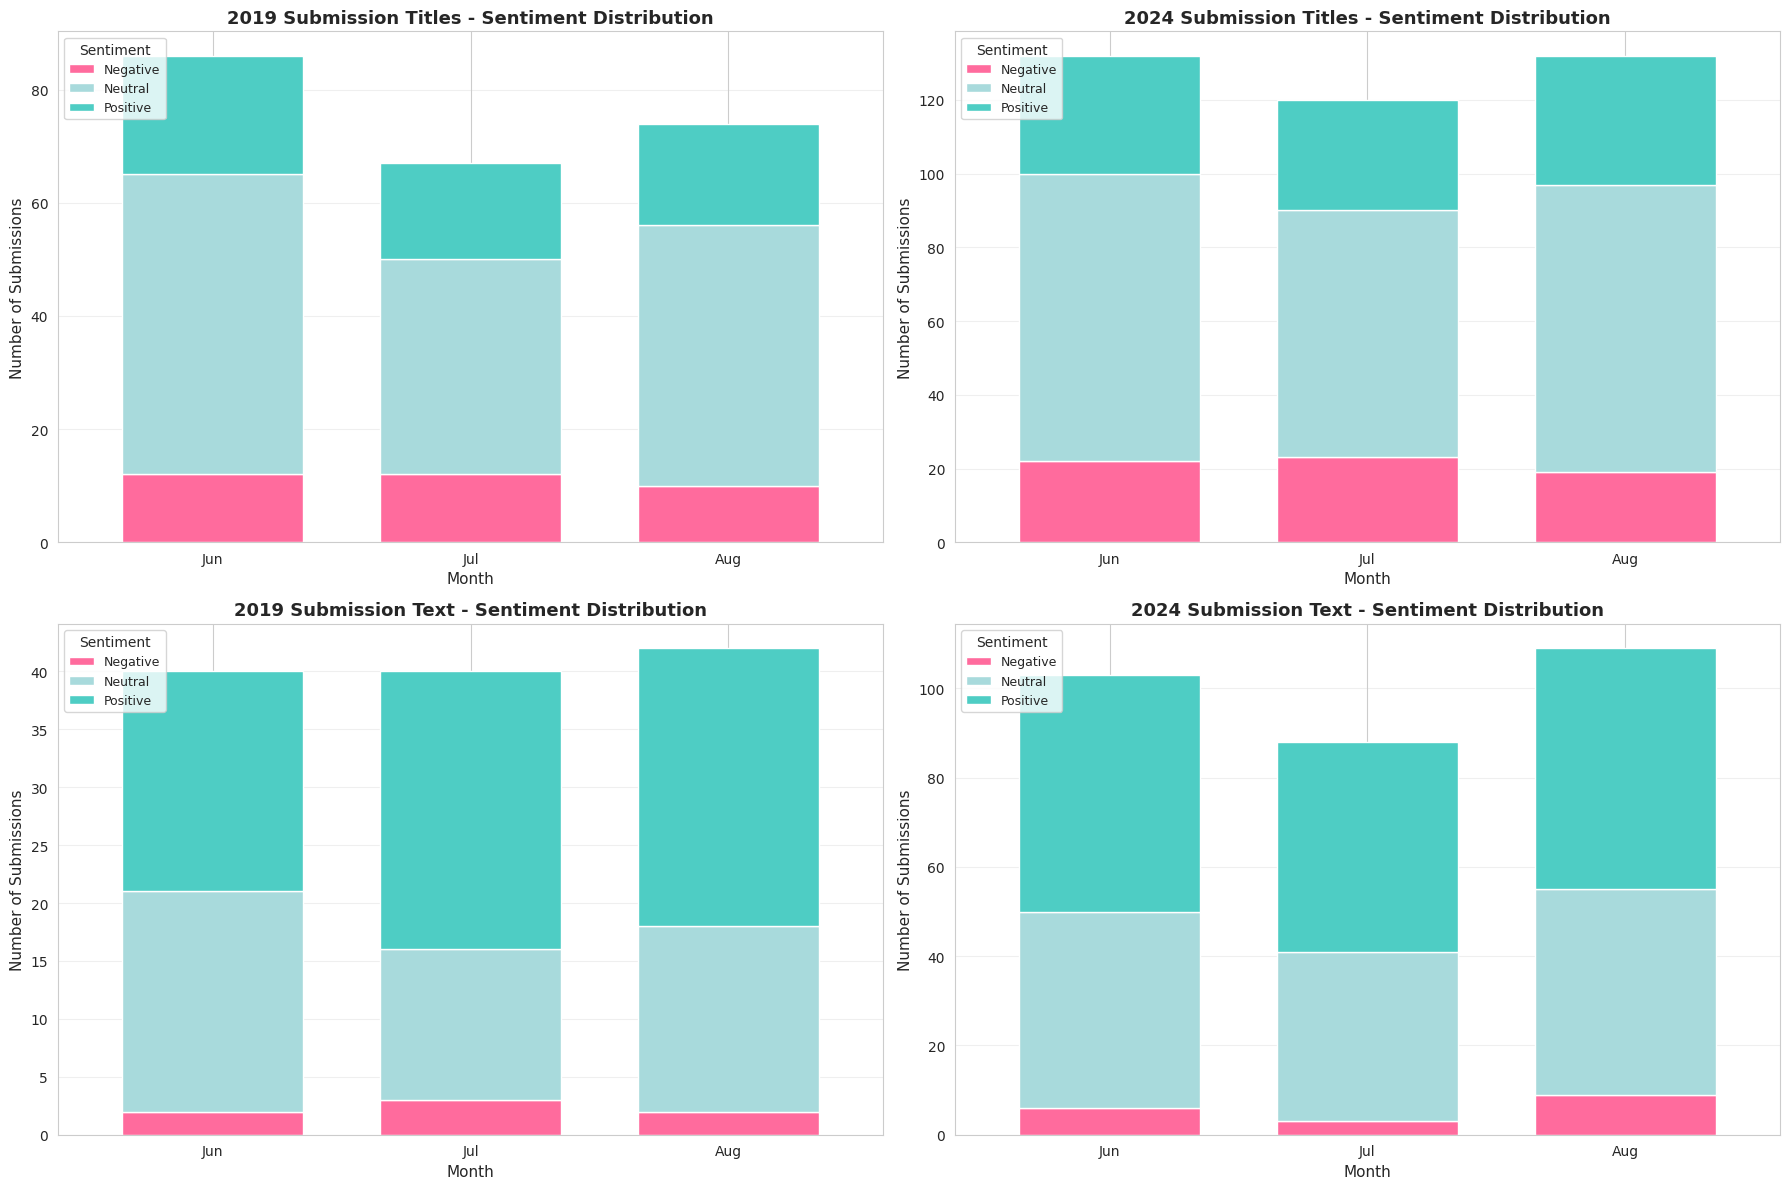

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
if sub_2019_sentiment is not None and 'title_category' in sub_2019_sentiment.columns:
    title_counts = sub_2019_sentiment.groupby(['month_name', 'title_category']).size().unstack(fill_value=0)

    for category in ['Negative', 'Neutral', 'Positive']:
        if category not in title_counts.columns:
            title_counts[category] = 0

    title_counts = title_counts[['Negative', 'Neutral', 'Positive']]
    month_order = ['Jun', 'Jul', 'Aug']
    title_counts = title_counts.reindex(month_order, fill_value=0)

    title_counts.plot(kind='bar', stacked=True, ax=ax,
                     color=['#FF6B9D', '#A8DADC', '#4ECDC4'],
                     width=0.7, edgecolor='white', linewidth=1)
    ax.set_title('2019 Submission Titles - Sentiment Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Number of Submissions', fontsize=11)
    ax.legend(title='Sentiment', loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
if sub_2024_sentiment is not None and 'title_category' in sub_2024_sentiment.columns:
    title_counts = sub_2024_sentiment.groupby(['month_name', 'title_category']).size().unstack(fill_value=0)

    for category in ['Negative', 'Neutral', 'Positive']:
        if category not in title_counts.columns:
            title_counts[category] = 0

    title_counts = title_counts[['Negative', 'Neutral', 'Positive']]
    title_counts = title_counts.reindex(month_order, fill_value=0)

    title_counts.plot(kind='bar', stacked=True, ax=ax,
                     color=['#FF6B9D', '#A8DADC', '#4ECDC4'],
                     width=0.7, edgecolor='white', linewidth=1)
    ax.set_title('2024 Submission Titles - Sentiment Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Number of Submissions', fontsize=11)
    ax.legend(title='Sentiment', loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

ax = axes[1, 0]
if sub_2019_sentiment is not None and 'text_category' in sub_2019_sentiment.columns:
    text_counts = sub_2019_sentiment.groupby(['month_name', 'text_category']).size().unstack(fill_value=0)

    for category in ['Negative', 'Neutral', 'Positive']:
        if category not in text_counts.columns:
            text_counts[category] = 0

    text_counts = text_counts[['Negative', 'Neutral', 'Positive']]
    text_counts = text_counts.reindex(month_order, fill_value=0)

    text_counts.plot(kind='bar', stacked=True, ax=ax,
                    color=['#FF6B9D', '#A8DADC', '#4ECDC4'],
                    width=0.7, edgecolor='white', linewidth=1)
    ax.set_title('2019 Submission Text - Sentiment Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Number of Submissions', fontsize=11)
    ax.legend(title='Sentiment', loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
if sub_2024_sentiment is not None and 'text_category' in sub_2024_sentiment.columns:
    text_counts = sub_2024_sentiment.groupby(['month_name', 'text_category']).size().unstack(fill_value=0)

    for category in ['Negative', 'Neutral', 'Positive']:
        if category not in text_counts.columns:
            text_counts[category] = 0

    text_counts = text_counts[['Negative', 'Neutral', 'Positive']]
    text_counts = text_counts.reindex(month_order, fill_value=0)

    text_counts.plot(kind='bar', stacked=True, ax=ax,
                    color=['#FF6B9D', '#A8DADC', '#4ECDC4'],
                    width=0.7, edgecolor='white', linewidth=1)
    ax.set_title('2024 Submission Text - Sentiment Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Number of Submissions', fontsize=11)
    ax.legend(title='Sentiment', loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The charts comparing sentiment for "Tradwife" submissions show a consistent prevalence of Neutral sentiment in both titles and text across all months in both 2019 and 2024. For Submission Titles, the absolute number of submissions increased dramatically in 2024, but the proportional share of Negative, Neutral, and Positive sentiment remained relatively stable, with Neutral sentiment dominating. In Submission Text, a similar pattern of increased volume in 2024 is observed, but the overall distribution remains largely consistent between the two years, suggesting that despite a surge in discussion volume, the fundamental emotional or objective tone used by users when posting did not undergo a major shift.

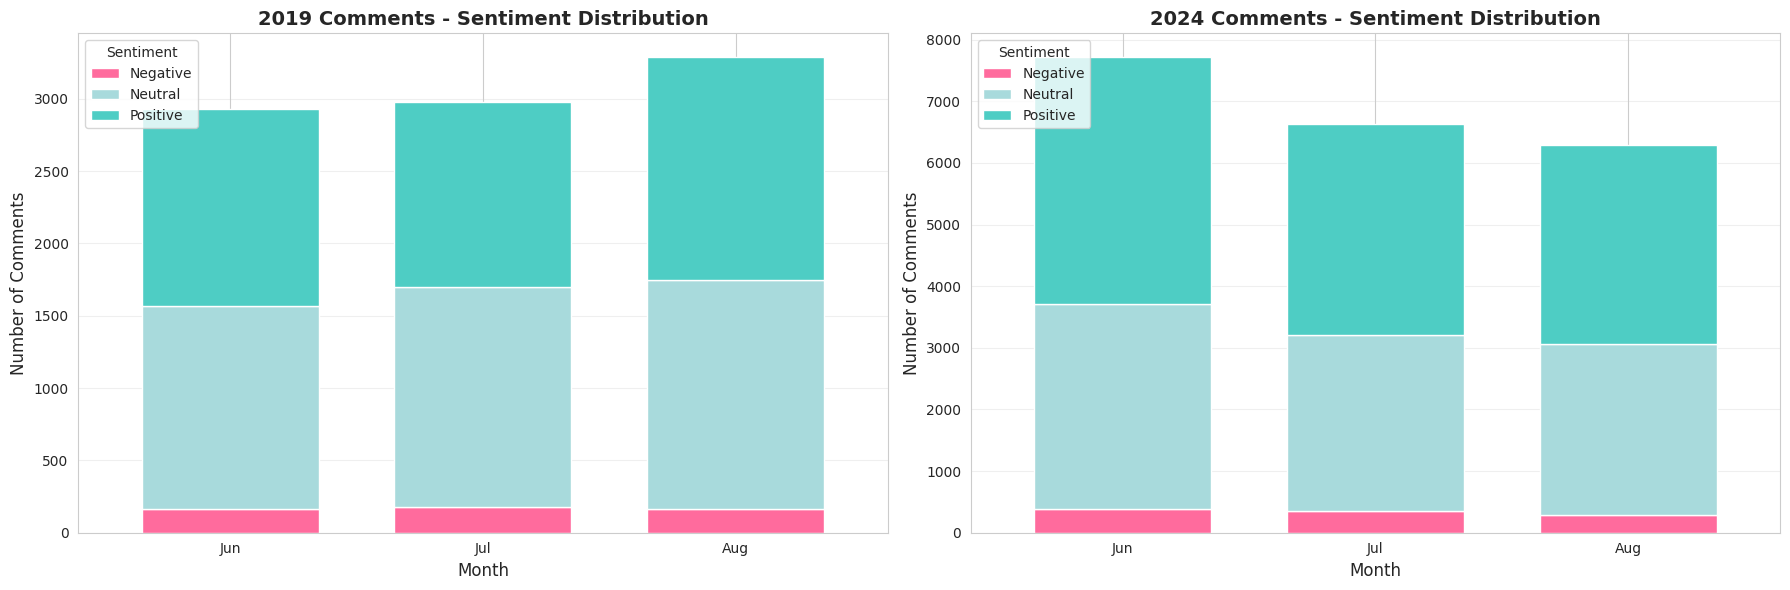

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 2019 Comment Sentiment
ax = axes[0]
if com_2019_sentiment is not None and 'text_category' in com_2019_sentiment.columns:
    comment_counts = com_2019_sentiment.groupby(['month_name', 'text_category']).size().unstack(fill_value=0)

    for category in ['Negative', 'Neutral', 'Positive']:
        if category not in comment_counts.columns:
            comment_counts[category] = 0

    comment_counts = comment_counts[['Negative', 'Neutral', 'Positive']]
    comment_counts = comment_counts.reindex(month_order, fill_value=0)

    comment_counts.plot(kind='bar', stacked=True, ax=ax,
                       color=['#FF6B9D', '#A8DADC', '#4ECDC4'],
                       width=0.7, edgecolor='white', linewidth=1)
    ax.set_title('2019 Comments - Sentiment Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Number of Comments', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

# 2024 Comment Sentiment
ax = axes[1]
if com_2024_sentiment is not None and 'text_category' in com_2024_sentiment.columns:
    comment_counts = com_2024_sentiment.groupby(['month_name', 'text_category']).size().unstack(fill_value=0)

    for category in ['Negative', 'Neutral', 'Positive']:
        if category not in comment_counts.columns:
            comment_counts[category] = 0

    comment_counts = comment_counts[['Negative', 'Neutral', 'Positive']]
    comment_counts = comment_counts.reindex(month_order, fill_value=0)

    comment_counts.plot(kind='bar', stacked=True, ax=ax,
                       color=['#FF6B9D', '#A8DADC', '#4ECDC4'],
                       width=0.7, edgecolor='white', linewidth=1)
    ax.set_title('2024 Comments - Sentiment Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Number of Comments', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

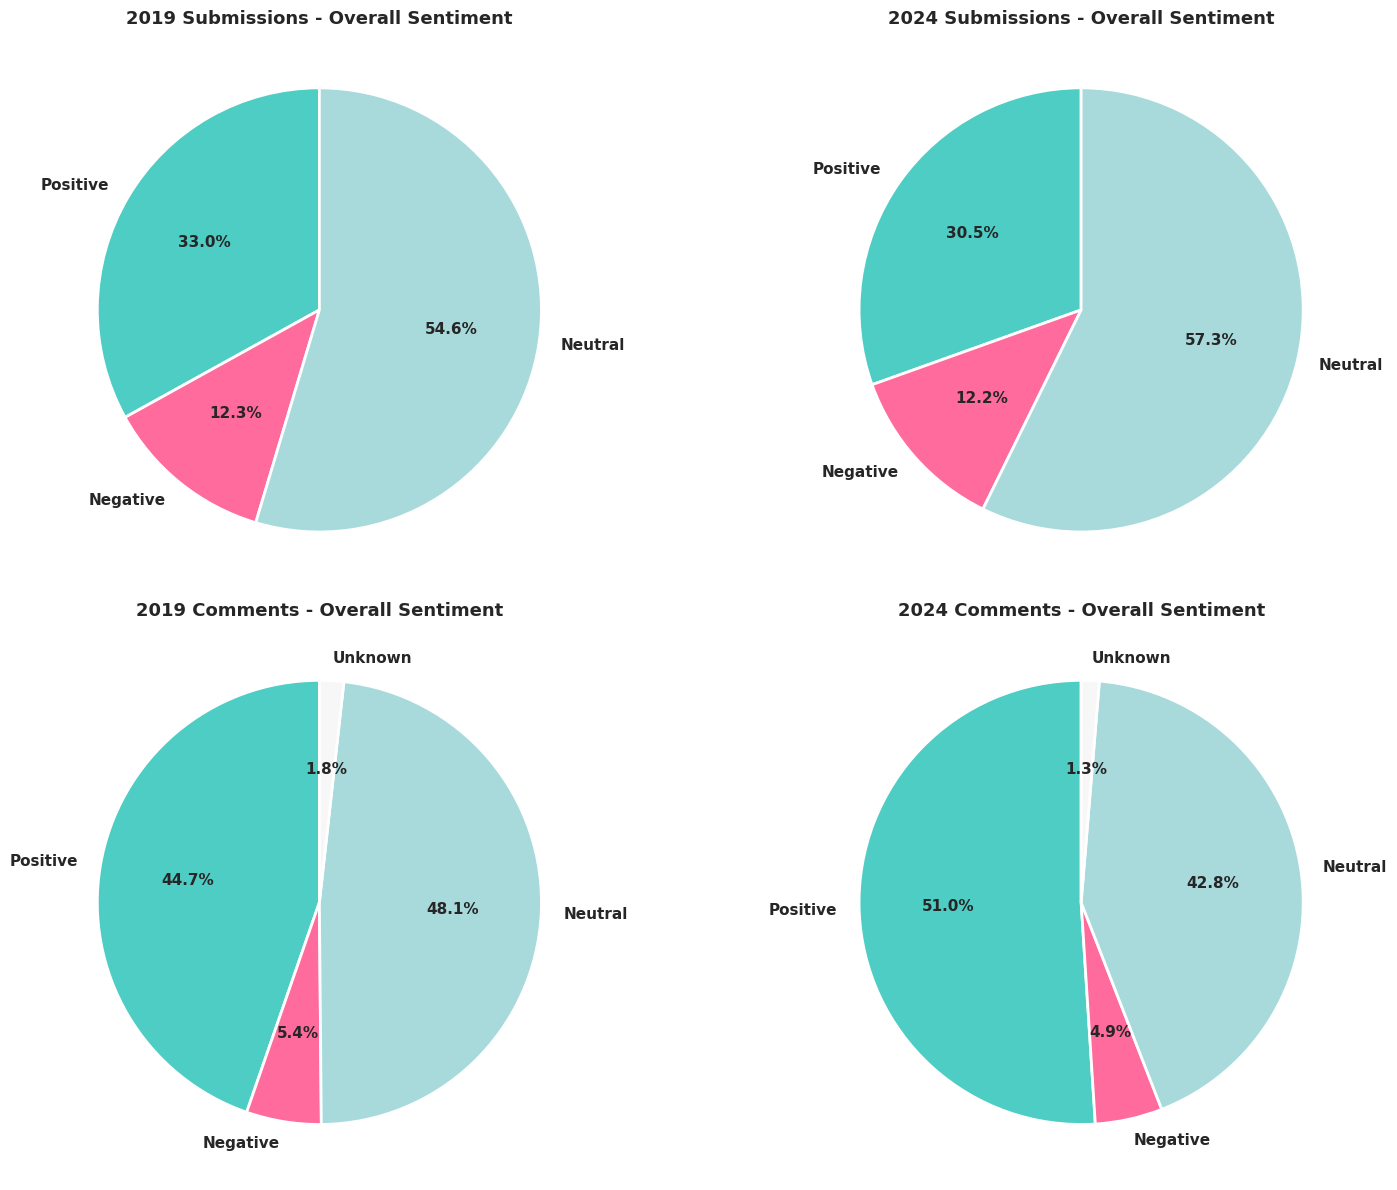

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = {'Negative': '#FF6B9D', 'Neutral': '#A8DADC', 'Positive': '#4ECDC4', 'Unknown': '#F7F7F7'}

plot_data = [
    (sub_2019_sentiment, 'combined_category', axes[0, 0], '2019 Submissions'),
    (sub_2024_sentiment, 'combined_category', axes[0, 1], '2024 Submissions'),
    (com_2019_sentiment, 'text_category', axes[1, 0], '2019 Comments'),
    (com_2024_sentiment, 'text_category', axes[1, 1], '2024 Comments'),
]

for df, category_col, ax, title in plot_data:
    if df is not None and category_col in df.columns:
        sentiment_dist = df[category_col].value_counts()

        # Ensure categories are ordered for consistent coloring
        ordered_index = [cat for cat in ['Positive', 'Negative', 'Neutral', 'Unknown'] if cat in sentiment_dist.index]
        sentiment_dist = sentiment_dist.reindex(ordered_index)

        pie_colors = [colors.get(cat, '#cccccc') for cat in sentiment_dist.index]

        ax.pie(sentiment_dist.values, labels=sentiment_dist.index, autopct='%1.1f%%',
               colors=pie_colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'},
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        ax.set_title(f'{title} - Overall Sentiment', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

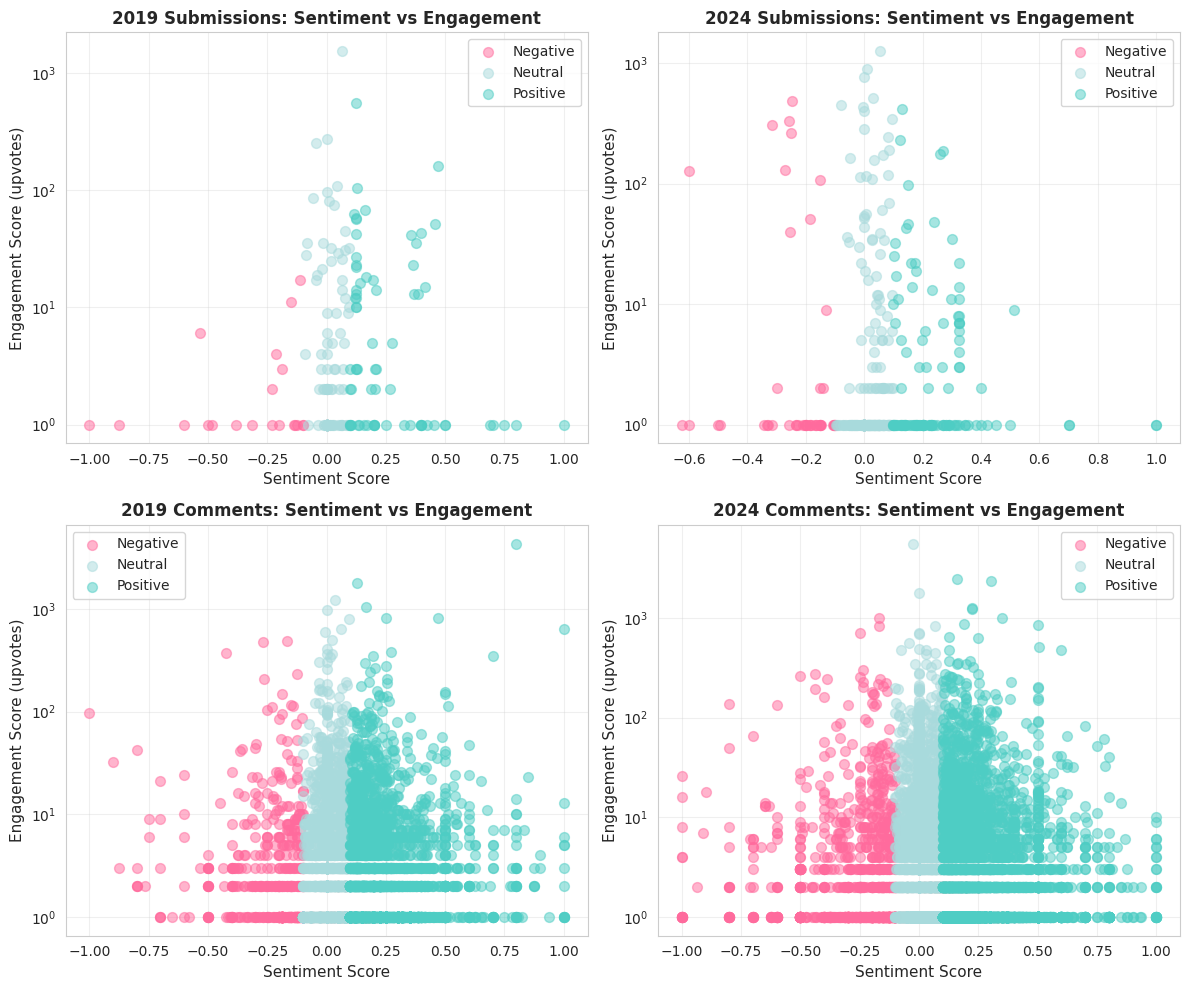

In [ ]:
def plot_sentiment_vs_engagement(df, ax, sentiment_col, category_col, year, content_type):
    if df is None or sentiment_col not in df.columns:
        return

    data = df[df[sentiment_col].notna()].copy()
    color_map = {'Negative': '#FF6B9D', 'Neutral': '#A8DADC', 'Positive': '#4ECDC4'}

    for category in ['Negative', 'Neutral', 'Positive']:
        cat_data = data[data[category_col] == category]
        if len(cat_data) > 0:
            ax.scatter(cat_data[sentiment_col], cat_data['score'],
                       alpha=0.5, s=50, label=category,
                       color=color_map.get(category))

    ax.set_xlabel('Sentiment Score', fontsize=11)
    ax.set_ylabel('Engagement Score (upvotes)', fontsize=11)
    ax.set_title(f'{year} {content_type}: Sentiment vs Engagement', fontweight='bold', fontsize=12)
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_sentiment_vs_engagement(sub_2019_sentiment, axes[0, 0], 'combined_sentiment', 'combined_category', 2019, 'Submissions')
plot_sentiment_vs_engagement(sub_2024_sentiment, axes[0, 1], 'combined_sentiment', 'combined_category', 2024, 'Submissions')
plot_sentiment_vs_engagement(com_2019_sentiment, axes[1, 0], 'text_sentiment', 'text_category', 2019, 'Comments')
plot_sentiment_vs_engagement(com_2024_sentiment, axes[1, 1], 'text_sentiment', 'text_category', 2024, 'Comments')

plt.tight_layout()
plt.show()

The plot shows a clear relationship between highly engaged content and Neutral or Positive sentiment in both years. For Submissions, scores exceeding 100 upvotes are predominantly Neutral or Positive in both 2019 and 2024, with Negative submissions rarely achieving high engagement. The Comments charts, which show a massive increase in volume in 2024, reveal a broader spread of highly engaged comments, but Neutral and Positive sentiment still account for the highest upvote totals. Importantly, in 2024, there is a visible increase in the number of highly engaged Negative comments compared to 2019, suggesting more polarized discussions are gaining traction.

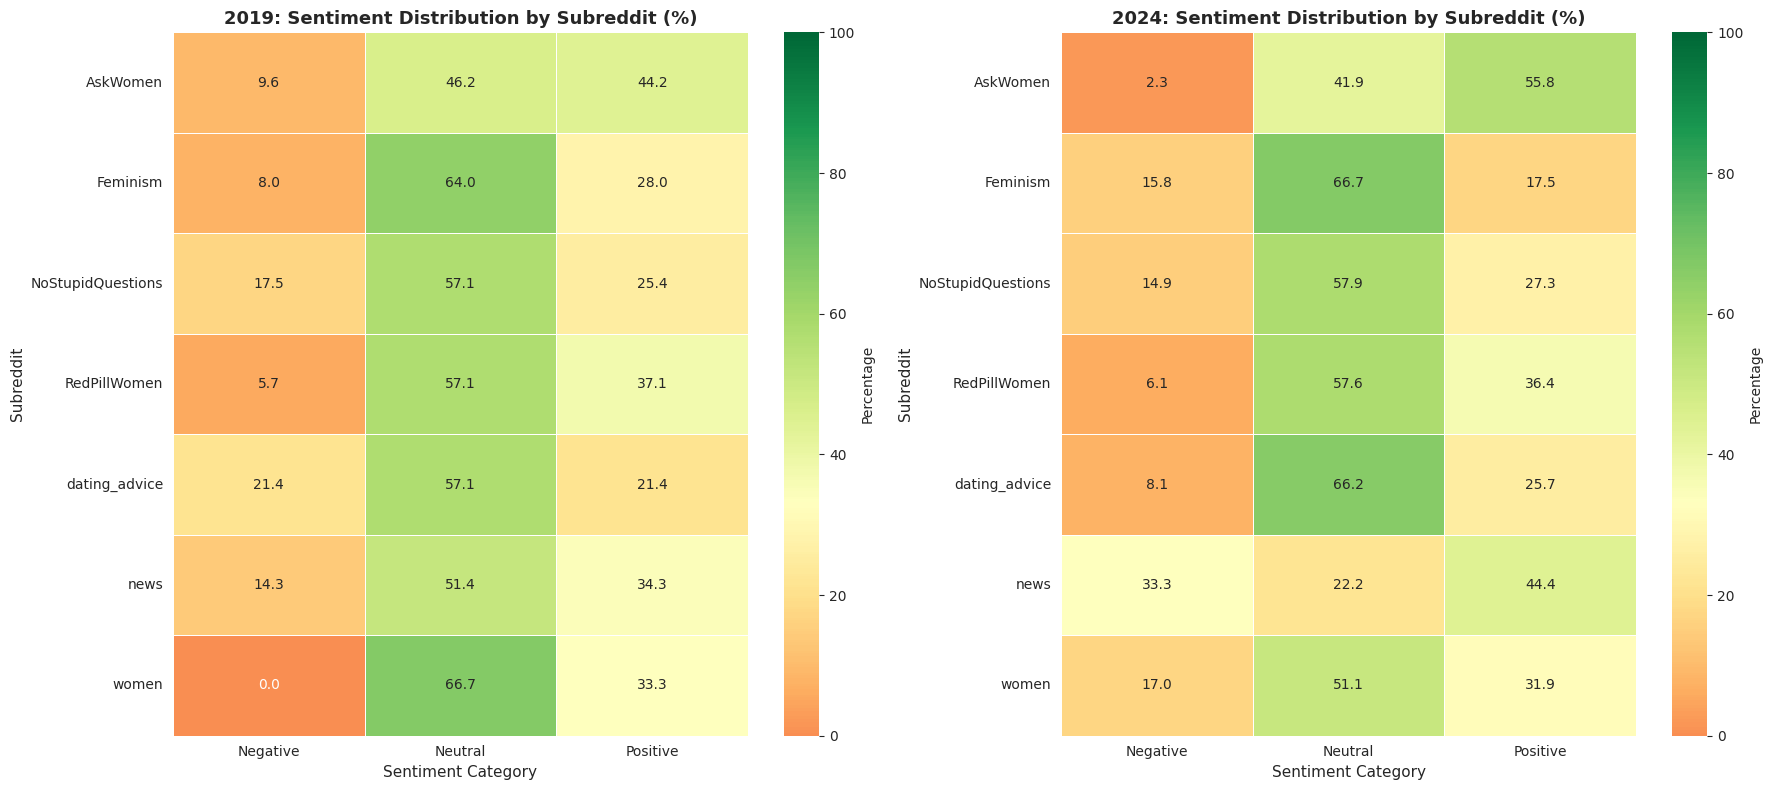

In [ ]:
def plot_subreddit_sentiment(df, ax, year, sentiment_col):
    if df is None or 'subreddit' not in df.columns:
        return

    top_subs = df['subreddit'].value_counts().head(15).index
    sub_data = df[df['subreddit'].isin(top_subs)]

    sentiment_matrix = sub_data.groupby(['subreddit', sentiment_col]).size().unstack(fill_value=0)

    for cat in ['Negative', 'Neutral', 'Positive']:
        if cat not in sentiment_matrix.columns:
            sentiment_matrix[cat] = 0

    sentiment_matrix = sentiment_matrix[['Negative', 'Neutral', 'Positive']]
    sentiment_pct = sentiment_matrix.div(sentiment_matrix.sum(axis=1), axis=0) * 100

    sns.heatmap(sentiment_pct, annot=True, fmt='.1f', cmap='RdYlGn',
                center=33, vmin=0, vmax=100, ax=ax,
                cbar_kws={'label': 'Percentage'}, linewidths=0.5)
    ax.set_title(f'{year}: Sentiment Distribution by Subreddit (%)', fontweight='bold', fontsize=13)
    ax.set_xlabel('Sentiment Category', fontsize=11)
    ax.set_ylabel('Subreddit', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_subreddit_sentiment(sub_2019_sentiment, axes[0], 2019, 'combined_category')
plot_subreddit_sentiment(sub_2024_sentiment, axes[1], 2024, 'combined_category')

plt.tight_layout()
plt.show()

Comparing the subreddit sentiment distributions across the two years reveals a general trend toward increased negativity in 2024 for several key communities. "NoStupidQuestions" saw its Negative sentiment share jump from $17.5\%$ to $34.9\%$, while its Neutral share dropped substantially, aligning with the topic's migration to this platform. Conversely, "dating_advice" showed a massive decrease in Negative sentiment from $21.4\%$ to just $8.1\%$, while subreddits like "AskWomen" and "Feminism" maintained high levels of Neutral and Positive sentiment. The data suggests that as the discussion centralized in "NoStupidQuestions", it became more contentious and polarized there, while other forums either stabilized or became less negative.

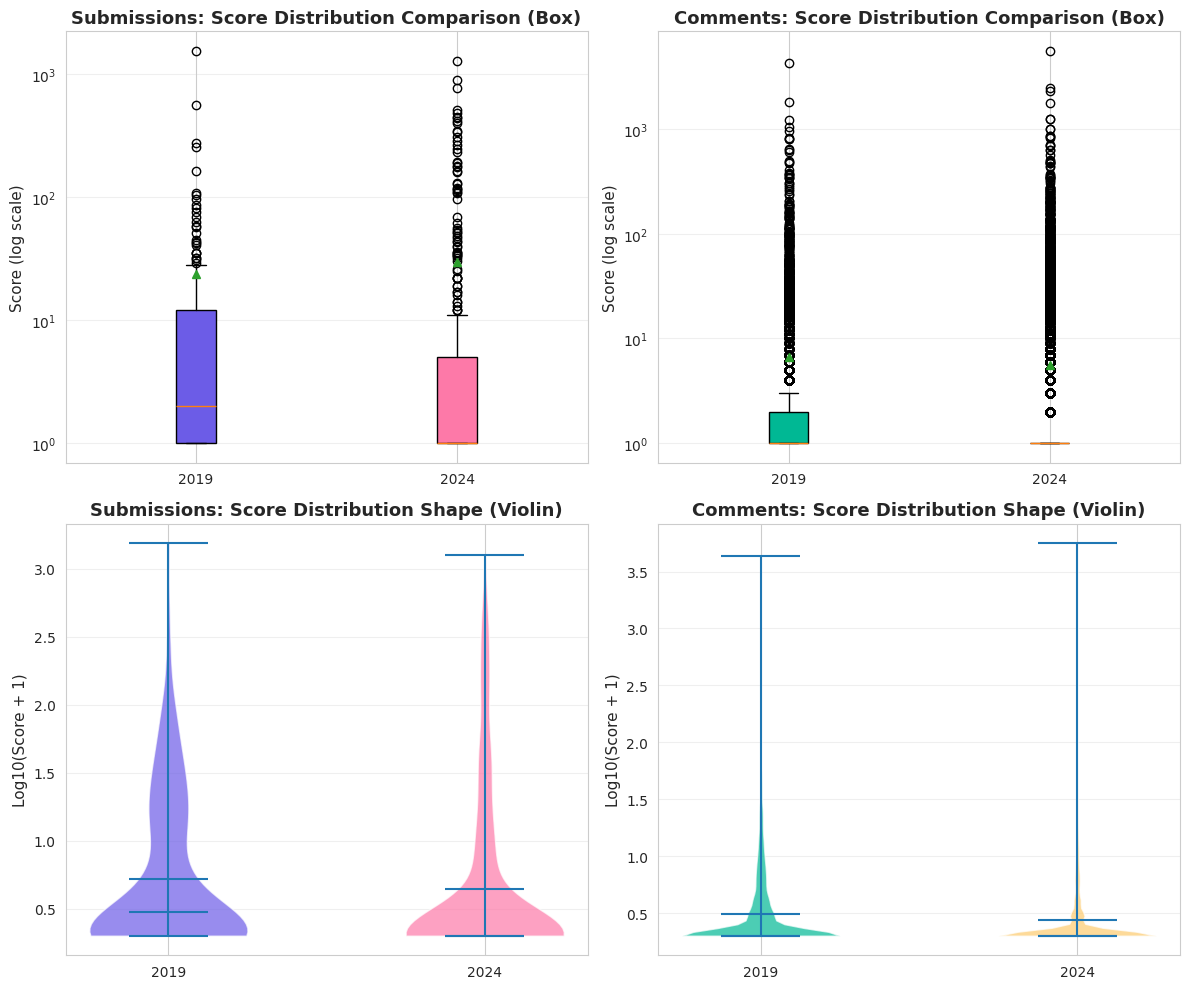

In [ ]:
def plot_engagement_distribution(df_2019, df_2024, ax_box, ax_violin, content_type, color_2019, color_2024):
    if df_2019 is None or df_2024 is None:
        return

    data_2019 = df_2019[df_2019['score'] > 0]['score']
    data_2024 = df_2024[df_2024['score'] > 0]['score']

    bp = ax_box.boxplot([data_2019, data_2024], labels=['2019', '2024'],
                         patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor(color_2019)
    bp['boxes'][1].set_facecolor(color_2024)

    ax_box.set_ylabel('Score (log scale)', fontsize=11)
    ax_box.set_title(f'{content_type}: Score Distribution Comparison (Box)', fontweight='bold', fontsize=13)
    ax_box.set_yscale('log')
    ax_box.grid(axis='y', alpha=0.3)

    df_plot = pd.DataFrame({
        '2019': np.log10(data_2019 + 1),
        '2024': np.log10(data_2024 + 1)
    })

    parts = ax_violin.violinplot([df_plot['2019'].dropna(), df_plot['2024'].dropna()],
                                 positions=[1, 2], showmeans=True, showmedians=True)

    colors = [color_2019, color_2024]
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)

    ax_violin.set_xticks([1, 2])
    ax_violin.set_xticklabels(['2019', '2024'])
    ax_violin.set_ylabel('Log10(Score + 1)', fontsize=11)
    ax_violin.set_title(f'{content_type}: Score Distribution Shape (Violin)', fontweight='bold', fontsize=13)
    ax_violin.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_engagement_distribution(sub_2019_sentiment, sub_2024_sentiment, axes[0, 0], axes[1, 0], 'Submissions', '#6C5CE7', '#FD79A8')
plot_engagement_distribution(com_2019_sentiment, com_2024_sentiment, axes[0, 1], axes[1, 1], 'Comments', '#00B894', '#FDCB6E')

plt.tight_layout()
plt.show()

For both Submissions and Comments, the median score remains very low in both years, as indicated by the box plots' placement near the bottom of the log-scale y-axis, but the range of outlier scores has increased substantially. The violin plots illustrate that the score distribution for both content types became much broader in 2024, with the distributions extending to higher log-scores, confirming that while most content receives minimal scores, the number of highly-engaged, high-scoring submissions and comments has grown considerably.

In [ ]:
def prepare_timeline_data(df, year):
    df_time = df.copy()

    if 'created' in df_time.columns:
        df_time['datetime'] = pd.to_datetime(df_time['created'], errors='coerce')
        df_time['date'] = df_time['datetime'].dt.date
        df_time['week'] = df_time['datetime'].dt.isocalendar().week
        df_time['day_of_week'] = df_time['datetime'].dt.day_name()
        df_time['hour'] = df_time['datetime'].dt.hour

        return df_time
    return None
sub_2019_time = prepare_timeline_data(sub_2019_sentiment, 2019)
sub_2024_time = prepare_timeline_data(sub_2024_sentiment, 2024)
com_2019_time = prepare_timeline_data(com_2019_sentiment, 2019)
com_2024_time = prepare_timeline_data(com_2024_sentiment, 2024)

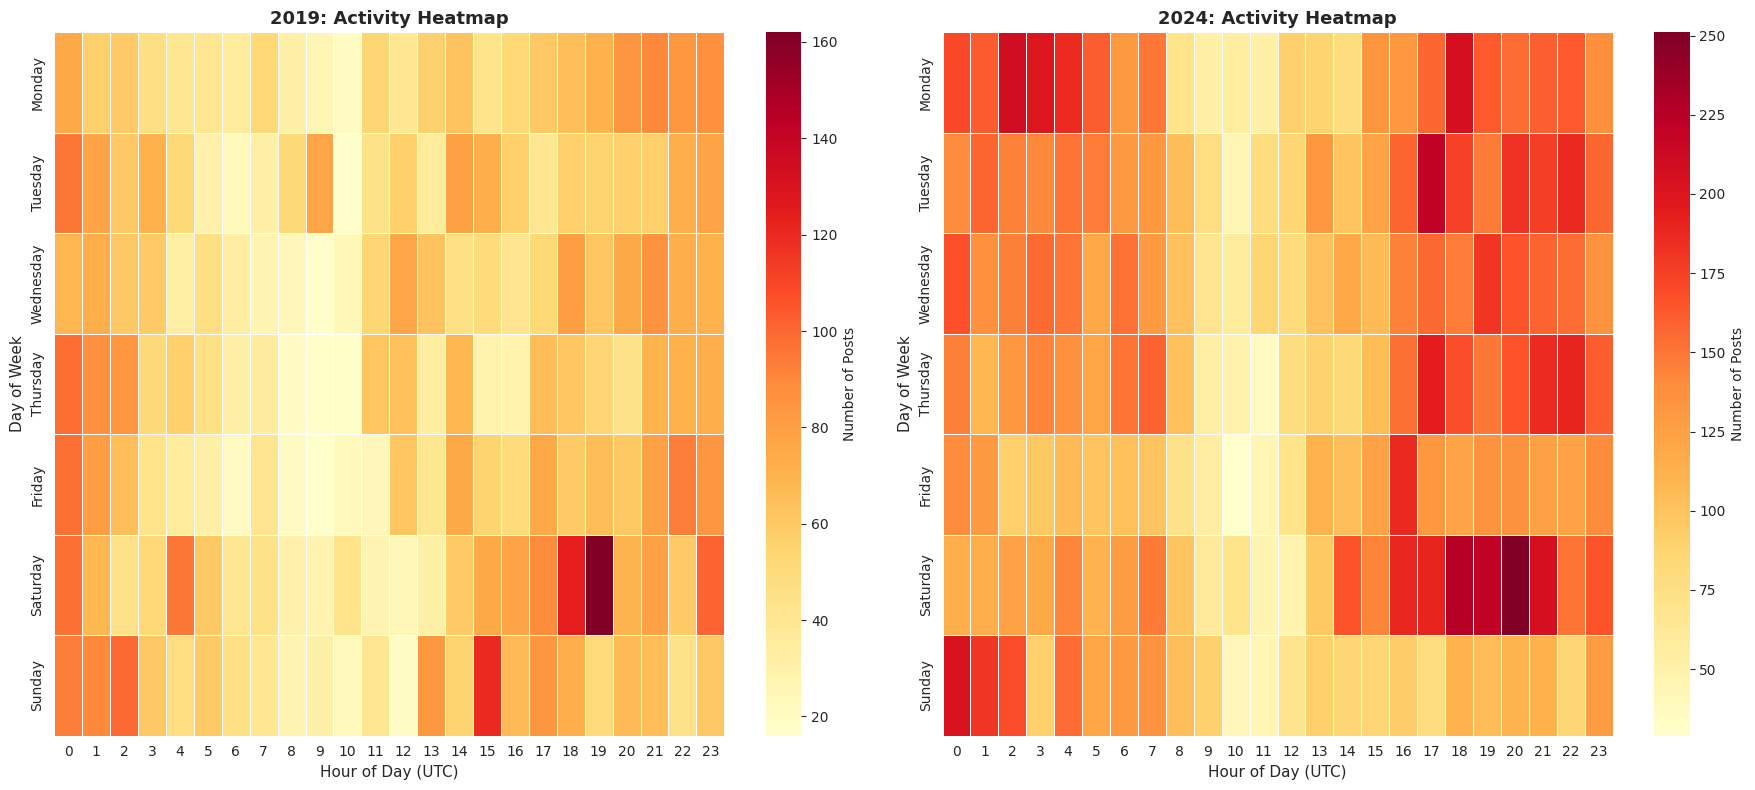

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

def plot_weekly_heatmap(df, ax, year):
    if df is None or 'day_of_week' not in df.columns or 'hour' not in df.columns:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        return

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    heatmap_data = df.groupby(['day_of_week', 'hour']).size().reset_index(name='count')
    heatmap_pivot = heatmap_data.pivot(index='day_of_week', columns='hour', values='count').fillna(0)
    heatmap_pivot = heatmap_pivot.reindex(day_order)

    sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, fmt='g',
                cbar_kws={'label': 'Number of Posts'}, ax=ax, linewidths=0.5)

    ax.set_xlabel('Hour of Day (UTC)', fontsize=11)
    ax.set_ylabel('Day of Week', fontsize=11)
    ax.set_title(f'{year}: Activity Heatmap', fontweight='bold', fontsize=13)

if sub_2019_time is not None and com_2019_time is not None:
    combined_2019 = pd.concat([sub_2019_time, com_2019_time])
    plot_weekly_heatmap(combined_2019, axes[0], 2019)

if sub_2024_time is not None and com_2024_time is not None:
    combined_2024 = pd.concat([sub_2024_time, com_2024_time])
    plot_weekly_heatmap(combined_2024, axes[1], 2024)

plt.tight_layout()
plt.show()

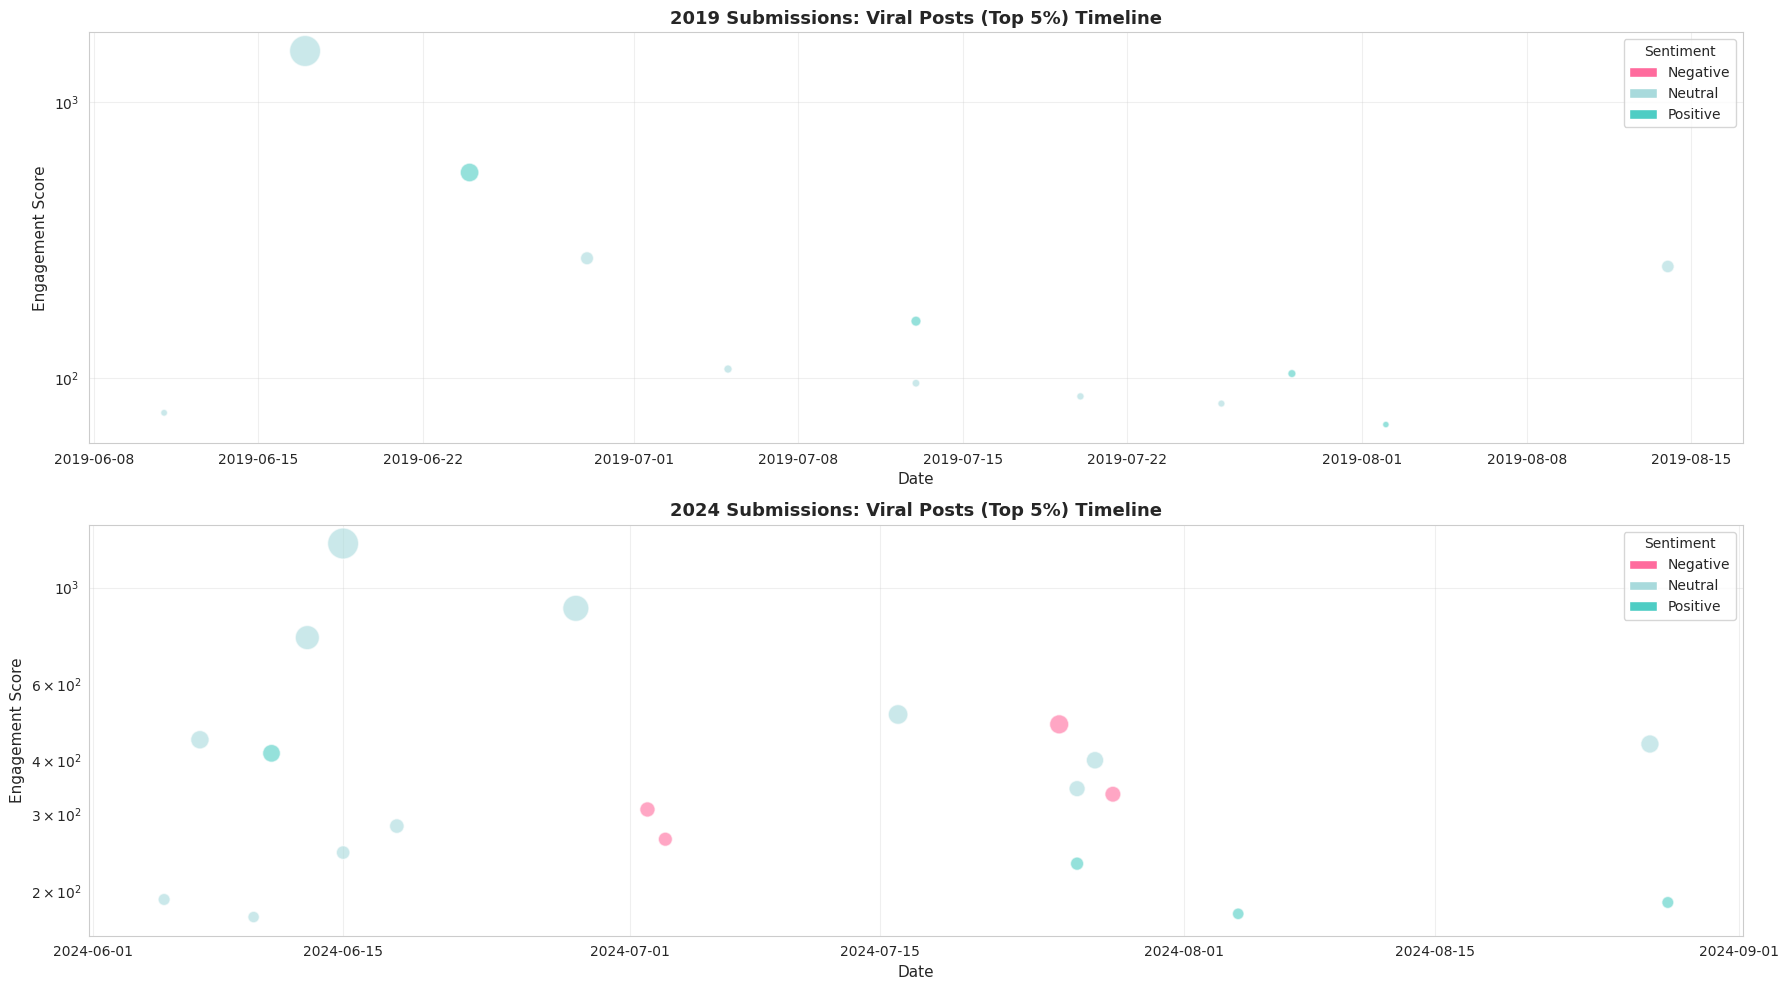

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

def plot_viral_timeline(df, ax, year, content_type):
    if df is None or 'date' not in df.columns or 'score' not in df.columns:
        return

    threshold = df['score'].quantile(0.95)
    viral_posts = df[df['score'] >= threshold].copy()

    if len(viral_posts) == 0:
        return

    dates = pd.to_datetime(viral_posts['date'])
    scores = viral_posts['score'].values

    sentiment_col = 'text_category' if content_type == 'Comments' else 'combined_category'
    colors = viral_posts[sentiment_col].map({
        'Negative': '#FF6B9D',
        'Neutral': '#A8DADC',
        'Positive': '#4ECDC4'
    })

    sizes = (scores / scores.max()) * 500

    scatter = ax.scatter(dates, scores, s=sizes, c=colors, alpha=0.6, edgecolors='white', linewidth=1)

    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Engagement Score', fontsize=11)
    ax.set_title(f'{year} {content_type}: Viral Posts (Top 5%) Timeline', fontweight='bold', fontsize=13)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    legend_elements = [
        Patch(facecolor='#FF6B9D', label='Negative'),
        Patch(facecolor='#A8DADC', label='Neutral'),
        Patch(facecolor='#4ECDC4', label='Positive')
    ]
    ax.legend(handles=legend_elements, title='Sentiment', loc='best')

if sub_2019_time is not None:
    plot_viral_timeline(sub_2019_time, axes[0], 2019, 'Submissions')

if sub_2024_time is not None:
    plot_viral_timeline(sub_2024_time, axes[1], 2024, 'Submissions')

plt.tight_layout()
plt.show()

The timeline of viral submissions (Top 5% by score) reveals a distinct change in activity between 2019 and 2024. In 2019, the highest-scoring viral posts were almost exclusively Neutral or Positive, with the largest post occurring around mid-June, and activity was sparse thereafter. In 2024, there's a greater concentration of viral posts earlier in June, and crucially, a cluster of highly engaged Negative submissions appeared around mid-July, which was largely absent in the 2019 data. Overall, 2024 shows a higher frequency of viral posts and the introduction of significantly negative, high-engagement content.